# Full LinkedIn Job Posting Dataset Exploration

In [1]:
#Loading The whole Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"E:\Analytic Plan BI\LinkedIn Dataset\linkedin_job_postings.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1348454
Number of columns: 14


In [3]:
# Inspecting the dataset structure
display(df.head())
display(df.tail())
df.info()
print(df.columns.tolist())

,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/group-unit-...,2024-01-19 09:45:09.215838+00,f,f,f,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",2024-01-17,Gadsden,United States,Supervisor Travel-Information Center,Mid senior,Onsite


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
1348449,https://www.linkedin.com/jobs/view/registered-...,2024-01-20 15:21:07.786118+00,t,t,f,Registered Nurse (RN) #CP-RN-7998660 - 2411627...,TravelNurseSource,"Providence, RI",2024-01-14,Fall River,United States,Nurse Supervisor,Mid senior,Onsite
1348450,https://www.linkedin.com/jobs/view/constructio...,2024-01-20 15:21:10.885264+00,t,t,f,Construction Superintendent,Jobot,"New Iberia, LA",2024-01-15,Lafayette,United States,Assistant Construction Superintendent,Mid senior,Onsite
1348451,https://www.linkedin.com/jobs/view/executive-c...,2024-01-21 07:40:00.304641+00,t,t,f,"Executive Chef, Operations Support",NEXDINE Hospitality,"Riverhead, NY",2024-01-14,Eastport,United States,Chef,Mid senior,Onsite
1348452,https://www.linkedin.com/jobs/view/rn-register...,2024-01-21 00:38:39.816821+00,t,t,f,"RN- Registered Nurse, Analyst - - 23934913EXPP...",TravelNurseSource,"Aurora, CO",2024-01-16,Colorado,United States,Occupational Analyst,Mid senior,Onsite
1348453,https://www.linkedin.com/jobs/view/on-demand-g...,2024-01-21 00:38:44.231492+00,t,t,f,"On-Demand: Guest Advocate (Cashier), General M...",Target,"Culver City, CA",2024-01-12,Malibu,United States,Cashier Ii,Mid senior,Onsite


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348454 entries, 0 to 1348453
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   job_link             1348454 non-null  object
 1   last_processed_time  1348454 non-null  object
 2   got_summary          1348454 non-null  object
 3   got_ner              1348454 non-null  object
 4   is_being_worked      1348454 non-null  object
 5   job_title            1348454 non-null  object
 6   company              1348443 non-null  object
 7   job_location         1348435 non-null  object
 8   first_seen           1348454 non-null  object
 9   search_city          1348454 non-null  object
 10  search_country       1348454 non-null  object
 11  search_position      1348454 non-null  object
 12  job_level            1348454 non-null  object
 13  job_type             1348454 non-null  object
dtypes: object(14)
memory usage: 144.0+ MB
['job_link', 'last_processed

In [4]:
# Producing a basic variable profile set

profile = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notna().sum(),
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(3),
    "Unique Values": df.nunique(dropna=True)
})

display(profile)

,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values
job_link,object,1348454,0,0.000,1348454
last_processed_time,object,1348454,0,0.000,722748
got_summary,object,1348454,0,0.000,2
got_ner,object,1348454,0,0.000,2
is_being_worked,object,1348454,0,0.000,2
job_title,object,1348454,0,0.000,584544
company,object,1348443,11,0.001,90605
job_location,object,1348435,19,0.001,29153
first_seen,object,1348454,0,0.000,6
search_city,object,1348454,0,0.000,1018


In [5]:
# Checking Missing values

missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(4)
})

missing = missing.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(missing)

,Missing_Count,Missing_Percentage
job_location,19,0.0014
company,11,0.0008
got_summary,0,0.0000
got_ner,0,0.0000
job_link,0,0.0000
last_processed_time,0,0.0000
job_title,0,0.0000
is_being_worked,0,0.0000
first_seen,0,0.0000
search_city,0,0.0000


In [6]:
display(
    missing[missing["Missing_Count"] > 0]
)

,Missing_Count,Missing_Percentage
job_location,19,0.0014
company,11,0.0008


In [7]:
#Checking for exact duplicate rows

exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)
print(
    "Exact duplicate percentage:",
    round(exact_duplicates / len(df) * 100, 4),
    "%"
)

Exact duplicate rows: 0
Exact duplicate percentage: 0.0 %


In [8]:
# Checking for exact duplicate job posts

duplicate_links = df["job_link"].duplicated().sum()

print("Duplicate job_link values:", duplicate_links)
print(
    "Unique job_link values:",
    df["job_link"].nunique()
)

print(
    "Unique job_link percentage:",
    round(df["job_link"].nunique() / len(df) * 100, 4),
    "%"
)

Duplicate job_link values: 0
Unique job_link values: 1348454
Unique job_link percentage: 100.0 %


In [9]:
# Checking each categorical variable
categorical_columns = [
    "got_summary",
    "got_ner",
    "is_being_worked",
    "search_country",
    "job_level",
    "job_type"
]

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print("=" * 50)

    print(df[col].value_counts(dropna=False))


got_summary
got_summary
t    1297877
f      50577
Name: count, dtype: int64

got_ner
got_ner
t    1296401
f      52053
Name: count, dtype: int64

is_being_worked
is_being_worked
f    1346978
t       1476
Name: count, dtype: int64

search_country
search_country
United States     1149342
United Kingdom     113421
Canada              55972
Australia           29719
Name: count, dtype: int64

job_level
job_level
Mid senior    1204445
Associate      144009
Name: count, dtype: int64

job_type
job_type
Onsite    1337633
Hybrid       6562
Remote       4259
Name: count, dtype: int64


In [10]:
for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print("=" * 50)

    percentages = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    print(percentages)


got_summary
got_summary
t    96.25
f     3.75
Name: proportion, dtype: float64

got_ner
got_ner
t    96.14
f     3.86
Name: proportion, dtype: float64

is_being_worked
is_being_worked
f    99.89
t     0.11
Name: proportion, dtype: float64

search_country
search_country
United States     85.23
United Kingdom     8.41
Canada             4.15
Australia          2.20
Name: proportion, dtype: float64

job_level
job_level
Mid senior    89.32
Associate     10.68
Name: proportion, dtype: float64

job_type
job_type
Onsite    99.20
Hybrid     0.49
Remote     0.32
Name: proportion, dtype: float64


In [11]:
# Checking job_type

job_type_counts = df["job_type"].value_counts()

display(job_type_counts)

job_type
Onsite    1337633
Hybrid       6562
Remote       4259
Name: count, dtype: int64

In [12]:
job_type_percentage = (
    df["job_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(job_type_percentage)

job_type
Onsite    99.20
Hybrid     0.49
Remote     0.32
Name: proportion, dtype: float64

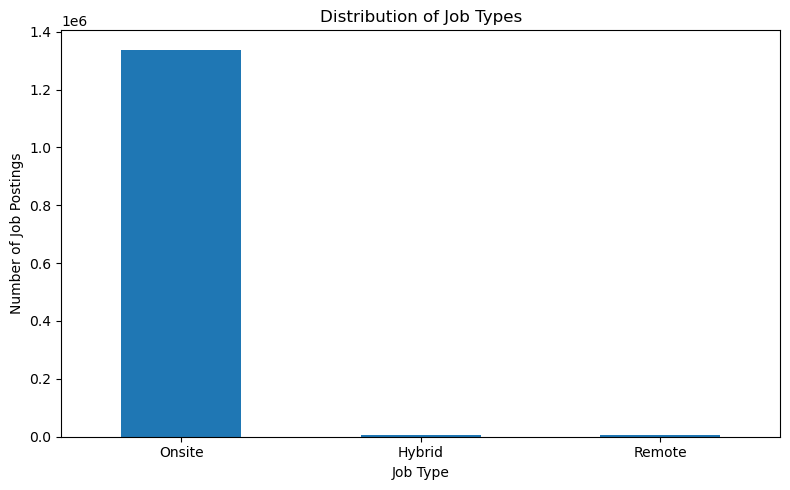

In [13]:
job_type_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Job Types")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Checking job_level

job_level_counts = df["job_level"].value_counts()

display(job_level_counts)

job_level
Mid senior    1204445
Associate      144009
Name: count, dtype: int64

In [15]:
job_level_percentage = (
    df["job_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(job_level_percentage)

job_level
Mid senior    89.32
Associate     10.68
Name: proportion, dtype: float64

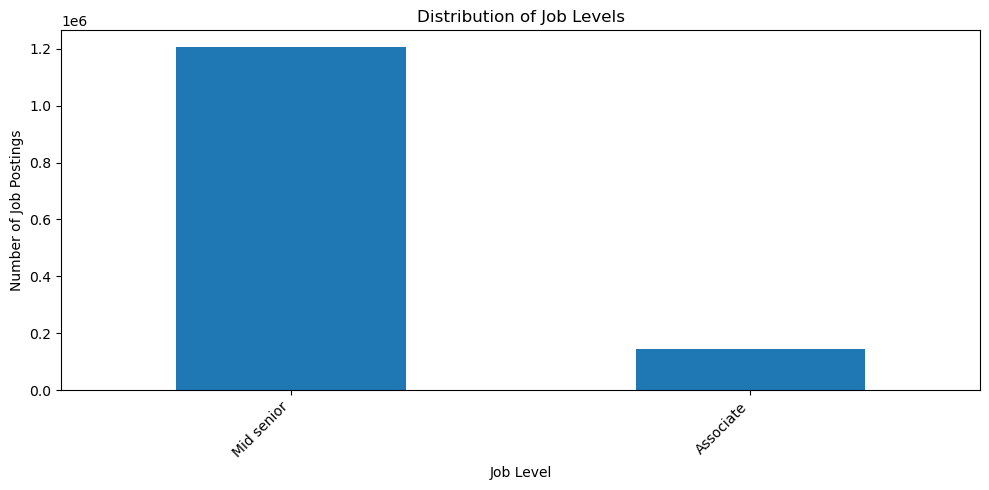

In [16]:
job_level_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribution of Job Levels")
plt.xlabel("Job Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
# Checking Geography

country_counts = df["search_country"].value_counts()

display(country_counts)

search_country
United States     1149342
United Kingdom     113421
Canada              55972
Australia           29719
Name: count, dtype: int64

In [18]:
country_percentage = (
    df["search_country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(country_percentage)

search_country
United States     85.23
United Kingdom     8.41
Canada             4.15
Australia          2.20
Name: proportion, dtype: float64

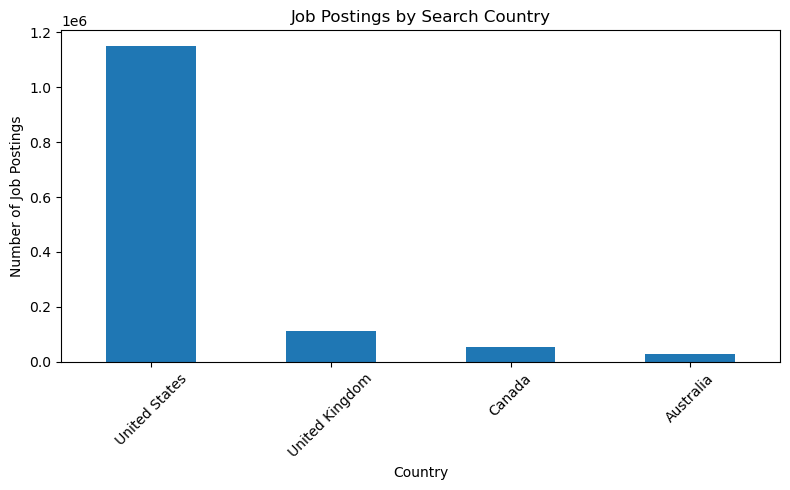

In [19]:
country_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Job Postings by Search Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Checking Cities
print(
    "Number of unique search cities:",
    df["search_city"].nunique()
)

Number of unique search cities: 1018


In [21]:
top_cities = df["search_city"].value_counts().head(20)

display(top_cities)

search_city
Baytown              10052
North Carolina       10015
Garland               9739
Greater London        9297
Austin                8897
South Carolina        8386
Sarnia-Clearwater     7887
Atlanta               7666
Indiana               7599
Alabama               7575
Hollywood             7398
Norristown            7377
Alexandria            7324
Santa Clara           7316
Chicago               7299
Glendale              7244
Pasadena              7181
Avondale              7153
Wisconsin             7073
San Antonio           6725
Name: count, dtype: int64

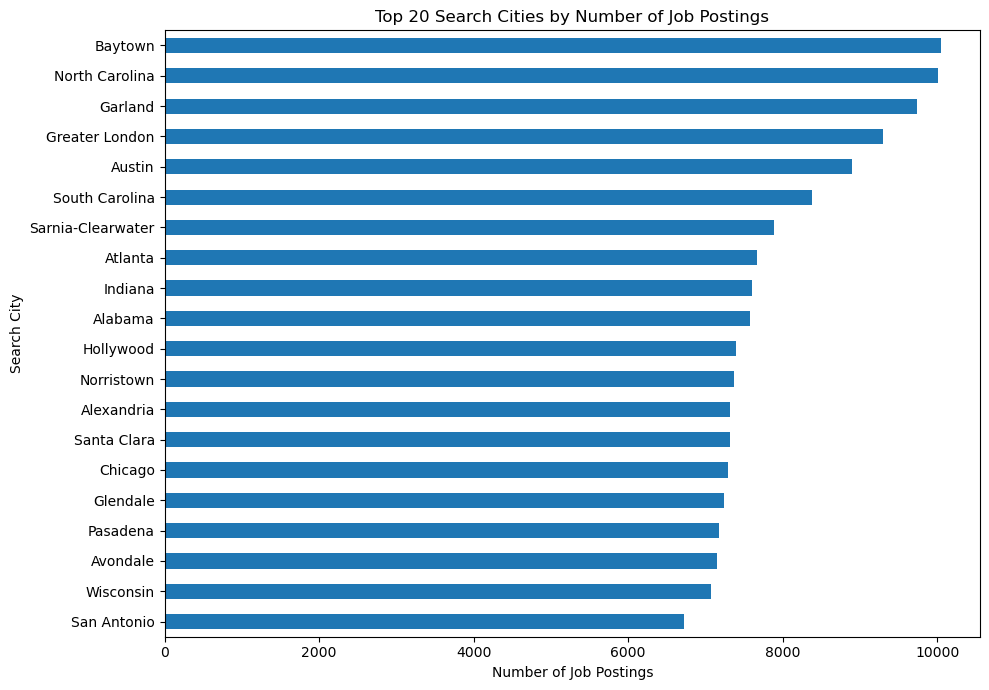

In [22]:
top_cities.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 20 Search Cities by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Search City")
plt.tight_layout()
plt.show()

In [23]:
# Checking Employer
print(
    "Unique companies:",
    df["company"].nunique()
)

Unique companies: 90605


In [24]:
top_companies = df["company"].value_counts().head(20)

display(top_companies)

company
Health eCareers                        41598
Jobs for Humanity                      27680
TravelNurseSource                      16142
Dollar General                         14815
PracticeLink                            9738
Energy Jobline                          9365
Gotham Enterprises Ltd                  8935
Jobot                                   8713
ClearanceJobs                           8599
McDonald's                              8125
VolunteerMatch                          6834
Walmart                                 6629
DocCafe                                 6106
H&R Block                               5697
Circle K                                5572
ClickJobs.io                            5570
CyberCoders                             5401
Michael Page                            4737
U.S. Department of Veterans Affairs     4564
BCG Attorney Search                     4558
Name: count, dtype: int64

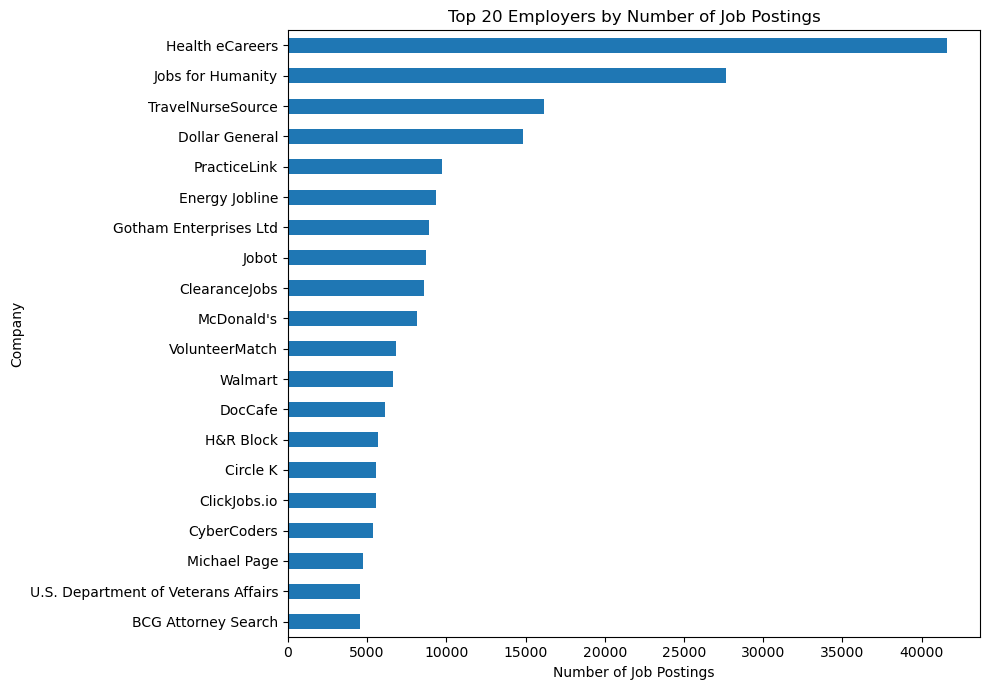

In [25]:
top_companies.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 20 Employers by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

In [26]:
# Checking job_titles
print(
    "Unique job titles:",
    df["job_title"].nunique()
)

Unique job titles: 584544


In [27]:
top_titles = df["job_title"].value_counts().head(30)

display(top_titles)

job_title
LEAD SALES ASSOCIATE-FT                                      7325
Shift Manager                                                5818
First Year Tax Professional                                  5356
Assistant Manager                                            5346
Customer Service Representative                              5203
LEAD SALES ASSOCIATE-PT                                      4924
Store Manager                                                4791
CUSTOMER SERVICE REPRESENTATIVE                              4218
Registered Nurse                                             4190
Hourly Supervisor & Training                                 2955
Travel Allied Health Professional - CT Technologist          2933
Host                                                         2871
Account Executive                                            2631
Senior Accountant                                            2548
Restaurant Manager                                           2335


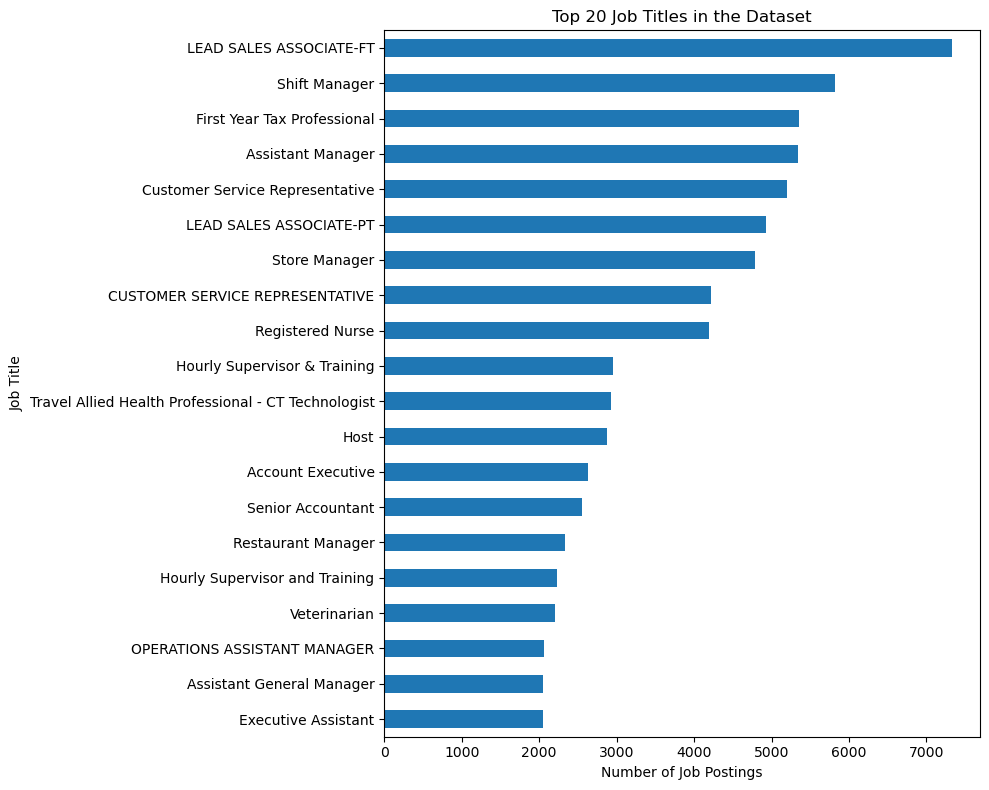

In [28]:
top_titles.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 20 Job Titles in the Dataset")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

In [29]:
# Checking Date/timeliness
print(df["first_seen"].head(20))
print(df["first_seen"].dtype)

0     2024-01-15
1     2024-01-14
2     2024-01-14
3     2024-01-16
4     2024-01-17
5     2024-01-16
6     2024-01-14
7     2024-01-16
8     2024-01-15
9     2024-01-14
10    2024-01-16
11    2024-01-14
12    2024-01-16
13    2024-01-14
14    2024-01-14
15    2024-01-14
16    2024-01-14
17    2024-01-14
18    2024-01-15
19    2024-01-13
Name: first_seen, dtype: object
object


In [30]:
df["first_seen_date"] = pd.to_datetime(
    df["first_seen"],
    errors="coerce"
)

In [31]:
print(
    "Earliest first_seen:",
    df["first_seen_date"].min()
)

print(
    "Latest first_seen:",
    df["first_seen_date"].max()
)

print(
    "Invalid/unparsed dates:",
    df["first_seen_date"].isna().sum()
)

Earliest first_seen: 2024-01-12 00:00:00
Latest first_seen: 2024-01-17 00:00:00
Invalid/unparsed dates: 0


In [32]:
# Checking Business Analyst prevalence

df["explicit_ba_title"] = (
    df["job_title"]
    .str.contains(
        r"\bbusiness analyst\b",
        case=False,
        na=False,
        regex=True
    )
)

In [33]:
ba_count = df["explicit_ba_title"].sum()

ba_percentage = (
    ba_count / len(df) * 100
)

print("Explicit Business Analyst postings:", ba_count)
print(
    "Percentage of complete dataset:",
    round(ba_percentage, 4),
    "%"
)

Explicit Business Analyst postings: 4546
Percentage of complete dataset: 0.3371 %


In [34]:
ba_titles = (
    df.loc[df["explicit_ba_title"], "job_title"]
    .value_counts()
    .head(30)
)

display(ba_titles)

job_title
Business Analyst                                         1011
Senior Business Analyst                                   211
JDE Business Analyst (Supply Chain)                       163
JD Edwards Business Analyst                               150
IT Business Analyst                                        64
Technical Business Analyst                                 60
Business Analyst II                                        51
Business Analyst III                                       36
Sr. Business Analyst                                       30
Business Analyst I                                         28
Salesforce Business Analyst                                26
Business Analyst (Bangkok Based, relocation provided)      22
Senior Financial Business Analyst - Tax Technology         22
Guidewire Business Analyst - Senior Associate              19
Lead Business Analyst                                      17
BUSINESS ANALYST - DUBAI, UAE                              1

# Full Job Skills Dataset Exploration


In [35]:
# Loading the whole 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

skills_path = r"E:\Analytic Plan BI\LinkedIn Dataset\job_skills.csv"

skills = pd.read_csv(skills_path)

print("Dataset loaded successfully.")
print("Rows:", skills.shape[0])
print("Columns:", skills.shape[1])

Dataset loaded successfully.
Rows: 1296381
Columns: 2


In [36]:
# Inspecting the dataset structure

display(skills.head(10))
skills.info()
print(skills.columns.tolist())

,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."
5,https://www.linkedin.com/jobs/view/senior-lead...,"Access Control, Video Management Systems, IPba..."
6,https://www.linkedin.com/jobs/view/program-con...,"Consultation, Supervision, InService Training,..."
7,https://www.linkedin.com/jobs/view/veterinary-...,"Veterinary Receptionist, AAHAaccredited, Custo..."
8,https://www.linkedin.com/jobs/view/sr-technici...,"Optical Inspection Equipment Programming, MS E..."
9,https://www.linkedin.com/jobs/view/experienced...,"HVAC, troubleshooting, Preventative maintenanc..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296381 entries, 0 to 1296380
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   job_link    1296381 non-null  object
 1   job_skills  1294296 non-null  object
dtypes: object(2)
memory usage: 19.8+ MB
['job_link', 'job_skills']


In [37]:
# Producing a basic variable profile set

skills_profile = pd.DataFrame({
    "Data Type": skills.dtypes.astype(str),
    "Non-Null Count": skills.notna().sum(),
    "Missing Count": skills.isna().sum(),
    "Missing %": (skills.isna().mean() * 100).round(4),
    "Unique Values": skills.nunique(dropna=True)
})

display(skills_profile)

,Data Type,Non-Null Count,Missing Count,Missing %,Unique Values
job_link,object,1296381,0,0.0000,1296381
job_skills,object,1294296,2085,0.1608,1287101


In [38]:
# Checking Missing values

missing_skills = pd.DataFrame({
    "Missing Count": skills.isna().sum(),
    "Missing Percentage": (
        skills.isna().mean() * 100
    ).round(4)
})

display(missing_skills)

,Missing Count,Missing Percentage
job_link,0,0.0000
job_skills,2085,0.1608


In [39]:
print(
    "Rows with missing job_link:",
    skills["job_link"].isna().sum()
)

print(
    "Rows with missing job_skills:",
    skills["job_skills"].isna().sum()
)

Rows with missing job_link: 0
Rows with missing job_skills: 2085


In [40]:
# Checking for Uniqueness

print("Total rows:", len(skills))

print(
    "Unique job links:",
    skills["job_link"].nunique()
)

print(
    "Duplicate job links:",
    skills["job_link"].duplicated().sum()
)

Total rows: 1296381
Unique job links: 1296381
Duplicate job links: 0


In [41]:
unique_percentage = (
    skills["job_link"].nunique()
    / len(skills)
    * 100
)

print(
    "Unique job_link percentage:",
    round(unique_percentage, 4),
    "%"
)

Unique job_link percentage: 100.0 %


In [42]:
# Checking for duplicate rows
exact_duplicates = skills.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

print(
    "Exact duplicate percentage:",
    round(exact_duplicates / len(skills) * 100, 4),
    "%"
)

Exact duplicate rows: 0
Exact duplicate percentage: 0.0 %


In [43]:
# Checking linkage with the postings dataset
skills_links = set(skills["job_link"].dropna())
posting_links = set(df["job_link"].dropna())

print("Job posting links:", len(posting_links))
print("Skills links:", len(skills_links))

matched = posting_links & skills_links

print("Matched job links:", len(matched))

Job posting links: 1348454
Skills links: 1296381
Matched job links: 1296381


In [44]:
coverage = (
    len(matched)
    / len(posting_links)
    * 100
)

print(
    "Percentage of job postings with skill records:",
    round(coverage, 2),
    "%"
)

Percentage of job postings with skill records: 96.14 %


In [45]:
postings_without_skills = posting_links - skills_links

print(
    "Job postings without skill records:",
    len(postings_without_skills)
)

Job postings without skill records: 52073


In [46]:
skills_without_postings = skills_links - posting_links

print(
    "Skill records without matching job posting:",
    len(skills_without_postings)
)

Skill records without matching job posting: 0


In [48]:
# Checking the job_skills field

pd.set_option("display.max_colwidth", 500)

display(
    skills["job_skills"].sample(
        20,
        random_state=42
    )
)

1035590                                                                                                                                                                                                                                                                                                                                                                                                                                          Team Building, Leadership, Communication, Collaboration, Diversity, Inclusion
793587                                                                                                                                                                                                                                                                       Nursing, Care Coordination, Patient Care, RN License, BSN or Commitment to Acquire, Acute Care Experience, Managerial Experience (Preferred), Equal Employment Opportunities (EEOC), Mental Health, Behavioral Health, Geria

In [49]:
# Checking Number of skills per posting

skills["skill_count"] = (
    skills["job_skills"]
    .fillna("")
    .apply(
        lambda x:
        len([s for s in x.split(",") if s.strip()])
    )
)

In [50]:
display(
    skills["skill_count"].describe()
)

count    1.296381e+06
mean     2.076954e+01
std      1.165239e+01
min      0.000000e+00
25%      1.300000e+01
50%      1.900000e+01
75%      2.500000e+01
max      4.630000e+02
Name: skill_count, dtype: float64

In [51]:
print(
    "Median skills per posting:",
    skills["skill_count"].median()
)

print(
    "Average skills per posting:",
    round(skills["skill_count"].mean(), 2)
)

print(
    "Maximum skills in one posting:",
    skills["skill_count"].max()
)

Median skills per posting: 19.0
Average skills per posting: 20.77
Maximum skills in one posting: 463


In [52]:
# Checking Distribution of skills count

skills["skill_count"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

0.50     19.0
0.75     25.0
0.90     34.0
0.95     41.0
0.99     61.0
1.00    463.0
Name: skill_count, dtype: float64

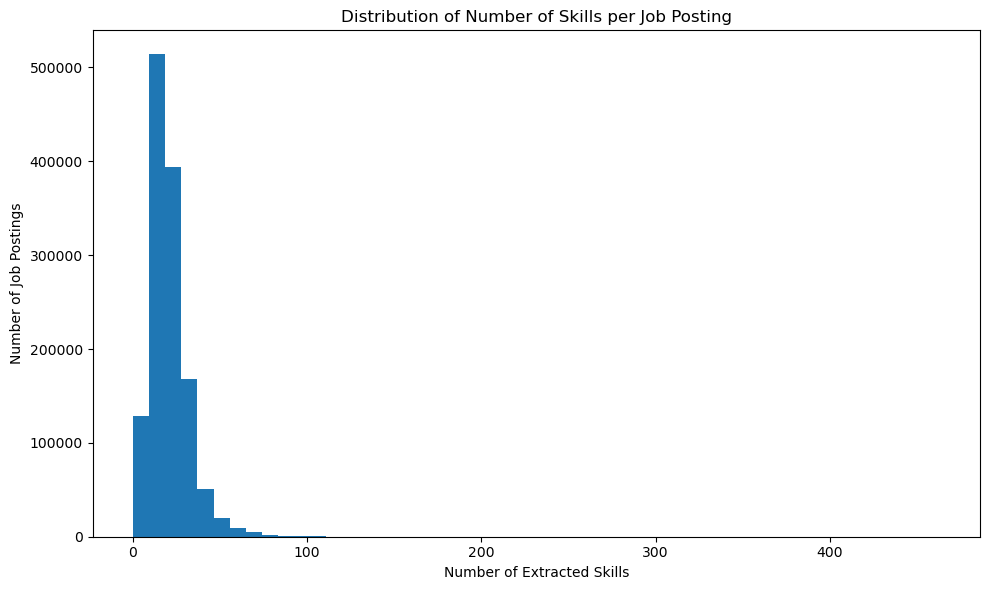

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(
    skills["skill_count"],
    bins=50
)

plt.title("Distribution of Number of Skills per Job Posting")
plt.xlabel("Number of Extracted Skills")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

In [54]:
# Finding suspicious skill counts
zero_skill_jobs = skills[
    skills["skill_count"] == 0
]

print(
    "Records with zero skills:",
    len(zero_skill_jobs)
)

Records with zero skills: 2085


In [55]:
display(
    skills[
        ["job_link", "job_skills", "skill_count"]
    ]
    .sort_values(
        "skill_count",
        ascending=False
    )
    .head(20)
)

,job_link,job_skills,skill_count
420273,https://uk.linkedin.com/jobs/view/clinical-theatre-manager-at-university-hospitals-bristol-and-weston-nhs-foundation-trust-3799930063,"Clinical Management, Leadership, Communication, Interpersonal skills, Teamwork, Patient Care, Safe and Effective Practice, Quality of Care, Operational Management, Clinical Expertise, Organisational Skills, Resourcefulness, Professionalism, Supervising, Advocacy, Education, Research, Innovation, ProblemSolving, DecisionMaking, Time Management, Conflict Resolution, Negotiation, Motivation, Delegation, Empowerment, Mentorship, Performance Management, Continuous Quality Improvement, Risk Manage...",463
280380,https://www.linkedin.com/jobs/view/cpd-supervisor-at-south-shore-health-3763307894,"Sterilization, Hospital policies, Material safety data sheets (MSDS), Surgical schedule, Surgical case cart system, Surgical equipment, Instrumentation, Medical/surgical devices and equipment, Microsurgery, Microsurgical techniques, Microsurgical instruments, Microsurgical procedures, Microsurgical training, Sterilization techniques, Aseptic technique, Microbiology, Inventory control, Surgical case cart system, In–house inventory tracking, Order coordinating and questions, Pricing, Surgeons’...",415
223863,https://www.linkedin.com/jobs/view/registered-nurse-rn-intensive-care-unit-springfield-regional-medical-center-full-time-nights-at-bon-secours-mercy-health-3714648331,"Patient Care, Medical/Surgical Nursing, Emergency Department Nursing, Critical Care Nursing, Stepdown Unit Nursing, Nursing Professional Practice Model, AACN Synergy Model, Quality Improvement, Patient Safety, Infection Control, Pharmacology, IV Therapy, Ventilator Management, CRRT, IABP, Impella, ECMO, Hemodynamic Monitoring, Trauma Nursing, Palliative Care, Ethics, Care Coordination, Patient Education, Interdisciplinary Collaboration, Communication Skills, Teamwork, Cultural Diversity, Inc...",375
1177602,https://www.linkedin.com/jobs/view/registered-nurse-specialist-medical-icu-at-beth-israel-lahey-health-3699050413,"Nurse, Specialist, ICU, Medical, Intensive, Care, Patient, Infectious, Disease, GI, Cardiac, Respiratory, Ventilator, Support, Invasive, Pressure, Monitoring, Clinical, Leader, Evidence, Based, Practice, Safe, Cost, Effective, Optimal, Nursing, Care, Multidisciplinary, Team, Holistic, Nursing, Approach, Comprehensive, Plan, of, Care, Patient, Family, Identifies, Prioritizes, Nursing, Care, Needs, Select, Population, Patients, Families, Develops, Implements, Care, Conferences, Programs, Indiv...",372
504190,https://www.linkedin.com/jobs/view/temporary-electrician-at-state-center-community-college-district-3767643979,"Electrical systems, Troubleshooting, Diagnosis, Repair, Electrical components, Devices, Motor controllers, Variable frequency drives, Switchgear, Control panels, Transformers, Solar panels, Lighting systems, Lighting panels, Conduits, Wiring, Optical fibers, Pull boxes, Switchboards, Controllers, Switches, Motors, Controls, Pumps, Metering equipment, HVAC, Highvoltage terminations, Splices, Infrared cameras, Vibration analysis, Testing devices, Ohmmeters, Voltmeters, Oscilloscopes, Handheld ...",320
55679,https://www.linkedin.com/jobs/view/construction-inspector-at-cole-associates-3790199560,"Construction methods, Equipment, Standards, Workmanship, Materials, Project plans, Specifications, Conformance, Established plans, State laws, District regulations, Reviews, Construction plans, Compliance, Rules, Regulations, Laws, Nonstructural plan checking, Constructability, Operational review, Plans, Specifications, Job drawings, Errors, Omissions, Potential problem areas, Change orders, Progress payments, Estimates of completion, Record maps, Data, Systems, Inspections, Field inspection...",288
1060804,https://www.linkedin.com/jobs/view/nurse-practitioner-stem-cell-transplant-at-vanderbilt-university-medical-center-3675143753,"Oncology, Hematology, Stem cell transplant, Medical knowl

In [56]:
# Explode the skill field
exploded_skills = (
    skills[
        ["job_link", "job_skills"]
    ]
    .dropna(subset=["job_skills"])
    .assign(
        skill=lambda x:
        x["job_skills"].str.split(",")
    )
    .explode("skill")
)

exploded_skills["skill"] = (
    exploded_skills["skill"]
    .str.strip()
)

display(exploded_skills.head(20))

,job_link,job_skills,skill
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Building Custodial Services
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Cleaning
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Janitorial Services
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Materials Handling
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Housekeeping
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Sanitation
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Waste Management
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Floor Maintenance
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Equipment Maintenance
0,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-university-3802280436,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handling, Housekeeping, Sanitation, Waste Management, Floor Maintenance, Equipment Maintenance, Safety Protocols, Communication Skills, Attention to Detail, Physical Strength, Experience in Housekeeping",Safety Protocols


In [57]:
print(
    "Individual skill observations:",
    len(exploded_skills)
)

print(
    "Unique raw skills:",
    exploded_skills["skill"].nunique()
)

Individual skill observations: 26925254
Unique raw skills: 3301513


In [58]:
# Check skill-name consistency
print(
    "Unique exact skill labels:",
    exploded_skills["skill"].nunique()
)

Unique exact skill labels: 3301513


In [60]:
exploded_skills["skill_normalised"] = (
    exploded_skills["skill"]
    .str.strip()
    .str.lower()
)

In [61]:
print(
    "Unique skills after basic normalisation:",
    exploded_skills[
        "skill_normalised"
    ].nunique()
)

Unique skills after basic normalisation: 2773203


In [62]:
# Most common skills in the entire dataset
top_skills = (
    exploded_skills["skill_normalised"]
    .value_counts()
    .head(30)
)

display(top_skills)

skill_normalised
communication             370143
customer service          278102
teamwork                  227609
communication skills      195949
leadership                185187
problem solving           149032
time management           142911
attention to detail       133975
problemsolving            129329
project management        121563
interpersonal skills      100267
patient care               99926
sales                      93031
nursing                    88015
collaboration              87116
training                   83656
data analysis              81964
microsoft office suite     75531
organizational skills      75274
inventory management       71911
high school diploma        67267
scheduling                 64461
bachelor's degree          63490
multitasking               62044
analytical skills          60768
microsoft office           60604
adaptability               59121
flexibility                56896
critical thinking          53081
documentation             

In [63]:
job_skill_unique = (
    exploded_skills[
        ["job_link", "skill_normalised"]
    ]
    .drop_duplicates()
)

In [64]:
skill_job_counts = (
    job_skill_unique[
        "skill_normalised"
    ]
    .value_counts()
)

top_skill_prevalence = pd.DataFrame({
    "Job Count": skill_job_counts.head(30)
})

top_skill_prevalence["% of Jobs With Skill"] = (
    top_skill_prevalence["Job Count"]
    / skills["job_link"].nunique()
    * 100
).round(2)

display(top_skill_prevalence)

,Job Count,% of Jobs With Skill
skill_normalised,,
communication,365931,28.23
customer service,276470,21.33
teamwork,226014,17.43
communication skills,195065,15.05
leadership,183681,14.17
problem solving,146018,11.26
time management,142010,10.95
attention to detail,132669,10.23
problemsolving,127040,9.80


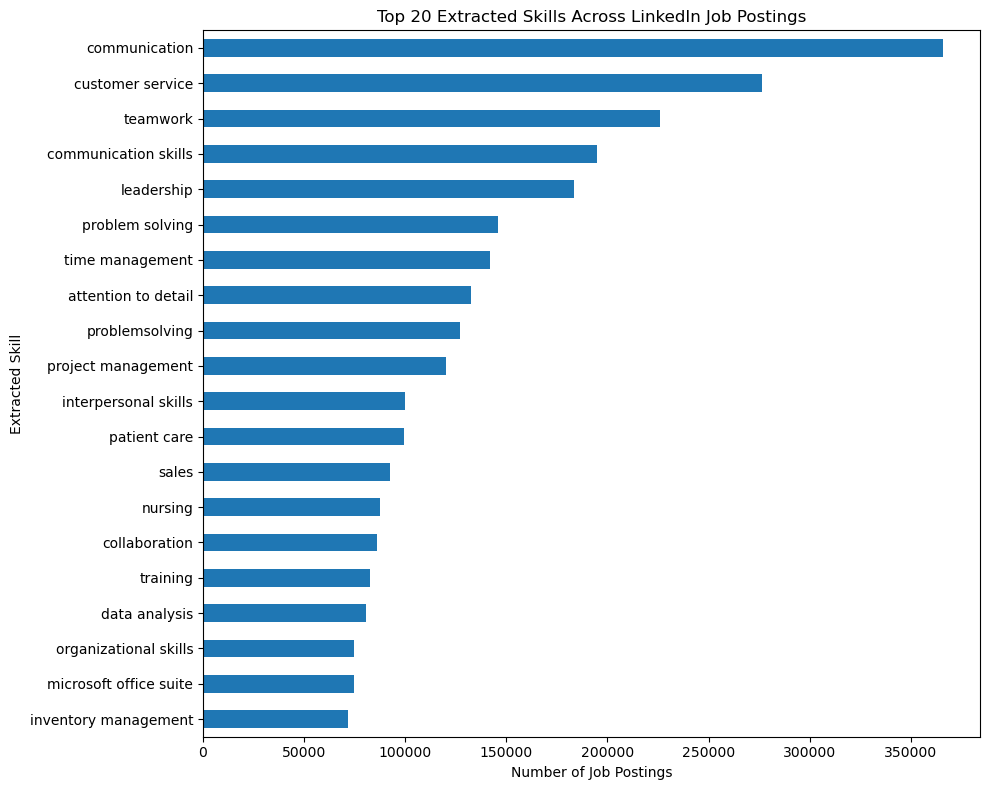

In [65]:
# Visualise the top skills

top20 = skill_job_counts.head(20)

top20.sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title(
    "Top 20 Extracted Skills Across LinkedIn Job Postings"
)

plt.xlabel(
    "Number of Job Postings"
)

plt.ylabel(
    "Extracted Skill"
)

plt.tight_layout()
plt.show()

In [66]:
# Check potentially noisy skill labels

skill_frequency = (
    job_skill_unique[
        "skill_normalised"
    ]
    .value_counts()
)

print(
    "Skills appearing in only 1 job:",
    (skill_frequency == 1).sum()
)

print(
    "Skills appearing in <= 5 jobs:",
    (skill_frequency <= 5).sum()
)

print(
    "Skills appearing in <= 10 jobs:",
    (skill_frequency <= 10).sum()
)

Skills appearing in only 1 job: 1955177
Skills appearing in <= 5 jobs: 2524275
Skills appearing in <= 10 jobs: 2629687


In [67]:
unique_skill_count = len(skill_frequency)

print(
    "% of unique skills appearing once:",
    round(
        (skill_frequency == 1).sum()
        / unique_skill_count
        * 100,
        2
    )
)

% of unique skills appearing once: 70.5


In [68]:
# Empty and suspicious strings
print(
    "Empty strings:",
    (exploded_skills["skill_normalised"] == "").sum()
)

Empty strings: 14


In [69]:
short_skills = (
    exploded_skills[
        exploded_skills[
            "skill_normalised"
        ].str.len() <= 2
    ]["skill_normalised"]
    .value_counts()
)

display(short_skills.head(50))

skill_normalised
rn    13714
cv     5831
r      4864
c#     4723
ai     3734
go     3542
it     3291
ct     2456
c      1911
hr     1726
5s     1706
md     1467
er     1152
s3      864
do      818
pc      767
pe      733
qa      729
jd      605
ob      582
gc      577
or      550
pa      509
rf      468
ca      467
bc      450
gi      432
ms      426
ed      419
p6      419
nx      413
8d      370
ip      369
ce      345
ea      341
iv      326
ma      323
ir      321
ux      300
ep      291
5g      288
f5      269
np      263
bi      261
pr      261
qc      252
ap      250
ui      246
ot      244
ar      240
Name: count, dtype: int64

In [4]:
import os

skills_path = r"E:\Analytic Plan BI\LinkedIn Dataset\job_skills.csv"

print("Exists:", os.path.exists(skills_path))
print("Is file:", os.path.isfile(skills_path))
print("Path:", skills_path)

Exists: True
Is file: True
Path: E:\Analytic Plan BI\LinkedIn Dataset\job_skills.csv


In [5]:
import pandas as pd

ba_skill_chunks = []

for chunk in pd.read_csv(
    skills_path,
    chunksize=100000,
    usecols=["job_link", "job_skills"]
):
    matched = chunk[
        chunk["job_skills"].str.contains(
            "business analy",
            case=False,
            na=False
        )
    ]

    if not matched.empty:
        ba_skill_chunks.append(matched)

ba_skill_candidates = pd.concat(
    ba_skill_chunks,
    ignore_index=True
)

print("Records containing 'business analy':", len(ba_skill_candidates))

pd.set_option("display.max_colwidth", 500)

display(
    ba_skill_candidates["job_skills"]
    .sample(
        min(30, len(ba_skill_candidates)),
        random_state=42
    )
)

Records containing 'business analy': 9357


2973    Business Analyst, Technical Support, Troubleshooting, Security Compliance, IT Security, Hardware Troubleshooting, Software Troubleshooting, Network Troubleshooting, Security Application Deployment, Technical Documentation, Problem Resolution, Internship Supervision, Mentorship, Security Training, Collaboration, Communication, ProblemSolving, Analytical Thinking, Attention to Detail, Bachelor's Degree, 24 Years of Experience, Standard Concepts and Practices, IT Procedures, EDI, Equity, Divers...
3396    Business Analysis, Financial Accounting, Budgeting, IT Systems, ERP, Requirements Gathering, System Enhancement, User Feedback, Quality Assurance, System Documentation, Test Script Creation, System Testing, Software Defect Resolution, Regression Testing, Application Help Desk Support, Oral and Written Communication, Problem Solving, Critical Thinking, Analytical Skills, Attention to Detail, Time Management, Interpersonal Skills, Customer Service, Oracle Database Concepts, Scripti

In [6]:
import pandas as pd

counts = {
    "Business Analyst": 0,
    "Business Analysis": 0,
    "Business Analytics": 0,
    "BA core union": 0,
    "All three union": 0
}

for chunk in pd.read_csv(
    skills_path,
    chunksize=100000,
    usecols=["job_skills"]
):

    ba_title = chunk["job_skills"].str.contains(
        r"\bbusiness analyst\b",
        case=False,
        na=False,
        regex=True
    )

    ba_analysis = chunk["job_skills"].str.contains(
        r"\bbusiness analysis\b",
        case=False,
        na=False,
        regex=True
    )

    ba_analytics = chunk["job_skills"].str.contains(
        r"\bbusiness analytics\b",
        case=False,
        na=False,
        regex=True
    )

    counts["Business Analyst"] += ba_title.sum()
    counts["Business Analysis"] += ba_analysis.sum()
    counts["Business Analytics"] += ba_analytics.sum()

    counts["BA core union"] += (
        ba_title | ba_analysis
    ).sum()

    counts["All three union"] += (
        ba_title | ba_analysis | ba_analytics
    ).sum()

for key, value in counts.items():
    print(key + ":", value)

Business Analyst: 1170
Business Analysis: 7154
Business Analytics: 1166
BA core union: 8137
All three union: 9265


In [8]:
import pandas as pd

# --------------------------------------------------
# 1. FILE PATHS
# --------------------------------------------------

postings_path = r"E:\Analytic Plan BI\LinkedIn Dataset\linkedin_job_postings.csv"
skills_path = r"E:\Analytic Plan BI\LinkedIn Dataset\job_skills.csv"


# --------------------------------------------------
# 2. LOAD ONLY REQUIRED POSTING COLUMNS
# --------------------------------------------------

jobs = pd.read_csv(
    postings_path,
    usecols=["job_link", "job_title"]
)

print("Job postings loaded:", len(jobs))


# --------------------------------------------------
# 3. TITLE-BASED BUSINESS ANALYST JOBS
# --------------------------------------------------

title_mask = jobs["job_title"].str.contains(
    r"\bbusiness analyst\b",
    case=False,
    na=False,
    regex=True
)

title_ba_links = set(
    jobs.loc[title_mask, "job_link"]
)


# --------------------------------------------------
# 4. SKILLS-BASED BUSINESS ANALYST JOBS
# --------------------------------------------------

skills_ba_links = set()

for chunk in pd.read_csv(
    skills_path,
    chunksize=100000,
    usecols=["job_link", "job_skills"]
):

    business_analyst = chunk["job_skills"].str.contains(
        r"\bbusiness analyst\b",
        case=False,
        na=False,
        regex=True
    )

    business_analysis = chunk["job_skills"].str.contains(
        r"\bbusiness analysis\b",
        case=False,
        na=False,
        regex=True
    )

    ba_skill_mask = business_analyst | business_analysis

    skills_ba_links.update(
        chunk.loc[ba_skill_mask, "job_link"].dropna()
    )


# --------------------------------------------------
# 5. COMPARE THE TWO METHODS
# --------------------------------------------------

both = title_ba_links & skills_ba_links

title_only = title_ba_links - skills_ba_links

skills_only = skills_ba_links - title_ba_links

combined = title_ba_links | skills_ba_links


# --------------------------------------------------
# 6. RESULTS
# --------------------------------------------------

print("\n--- BUSINESS ANALYST IDENTIFICATION ---")

print("Title-based BA jobs:", len(title_ba_links))
print("Skills-based BA jobs:", len(skills_ba_links))
print("Both title and skills:", len(both))
print("Title only:", len(title_only))
print("Skills only:", len(skills_only))
print("Combined BA-related jobs:", len(combined))


Job postings loaded: 1348454

--- BUSINESS ANALYST IDENTIFICATION ---
Title-based BA jobs: 4546
Skills-based BA jobs: 8137
Both title and skills: 2675
Title only: 1871
Skills only: 5462
Combined BA-related jobs: 10008


,Category,Number of Jobs
0,Title-based BA,4546
1,Skills-based BA,8137
2,Both title & skills,2675
3,Title only,1871
4,Skills only,5462
5,Combined BA-related,10008


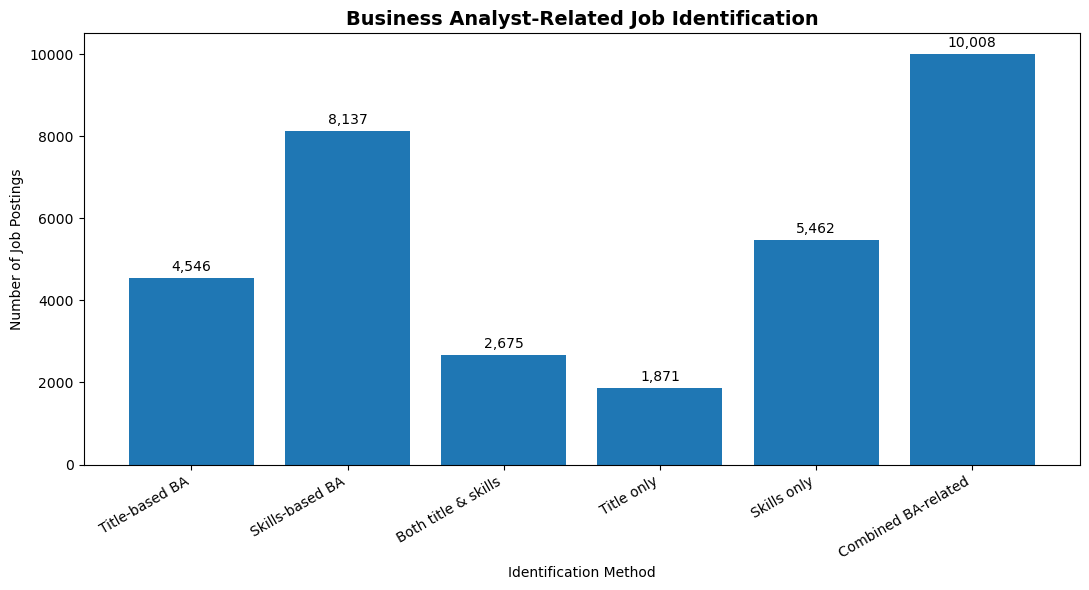

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Business Analyst identification results
ba_results = pd.DataFrame({
    "Category": [
        "Title-based BA",
        "Skills-based BA",
        "Both title & skills",
        "Title only",
        "Skills only",
        "Combined BA-related"
    ],
    "Number of Jobs": [
        4546,
        8137,
        2675,
        1871,
        5462,
        10008
    ]
})

display(ba_results)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    ba_results["Category"],
    ba_results["Number of Jobs"]
)

plt.title(
    "Business Analyst-Related Job Identification",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Identification Method")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=30, ha="right")

# Add values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 100,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

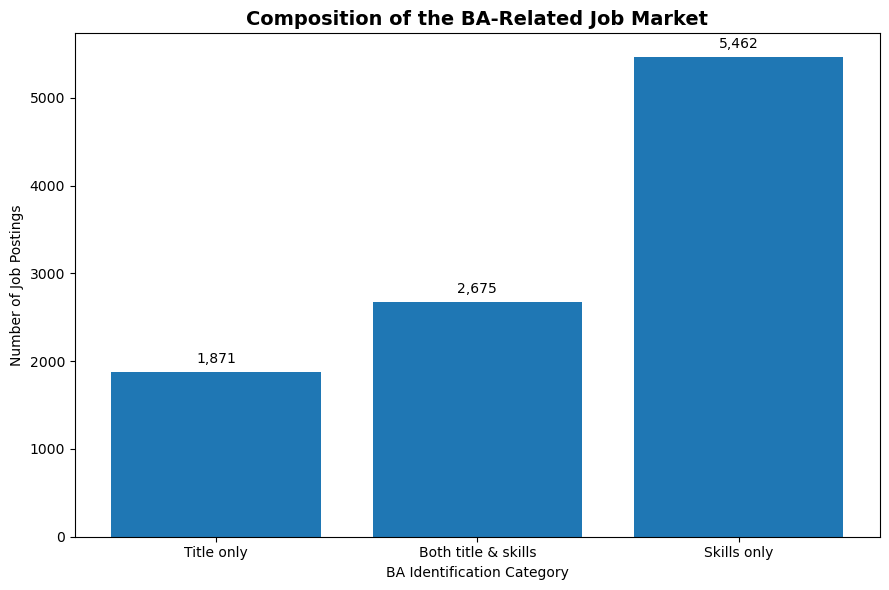

In [10]:
ba_overlap = pd.DataFrame({
    "Category": [
        "Title only",
        "Both title & skills",
        "Skills only"
    ],
    "Number of Jobs": [
        1871,
        2675,
        5462
    ]
})

plt.figure(figsize=(9, 6))

bars = plt.bar(
    ba_overlap["Category"],
    ba_overlap["Number of Jobs"]
)

plt.title(
    "Composition of the BA-Related Job Market",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("BA Identification Category")
plt.ylabel("Number of Job Postings")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 70,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [11]:
# Identify postings where BA appears in skills
# but "Business Analyst" is NOT in the job title

skills_only_jobs = jobs[
    jobs["job_link"].isin(skills_only)
].copy()

print("Skills-only BA jobs:", len(skills_only_jobs))

print("\nUnique job titles:")
print(skills_only_jobs["job_title"].nunique())

print("\nTop 30 job titles:")
display(
    skills_only_jobs["job_title"]
    .value_counts()
    .head(30)
)

Skills-only BA jobs: 5462

Unique job titles:
3832

Top 30 job titles:


job_title
Business Systems Analyst                                                                   58
Tax-Partnership Allocation Reporting Solutions - Manager                                   44
Store Manager                                                                              36
Senior Project Manager                                                                     33
Technical Project Manager                                                                  31
Manager, Marketing Strategy & Analytics (Bangkok-based, relocation provided)               27
Senior Data Analyst (Product Team) (Bangkok Based, relocation provided)                    22
Senior Financial Analyst                                                                   22
Senior Analyst / Analyst (Bangkok Based, relocation provided)                              21
Data Analyst (Bangkok Based, relocation provided)                                          20
Senior Analyst (Bangkok Based, relocation provided

In [12]:
display(
    skills_only_jobs[
        ["job_title", "job_link"]
    ]
    .sample(30, random_state=42)
)

,job_title,job_link
160342,"Senior Associate, Product Manager - Marketing Technology",https://www.linkedin.com/jobs/view/senior-associate-product-manager-marketing-technology-at-capital-one-3792300475
867781,Business Systems Analyst - IV,https://www.linkedin.com/jobs/view/business-systems-analyst-iv-at-apex-systems-3798840194
9192,Business Process Analyst Director,https://www.linkedin.com/jobs/view/business-process-analyst-director-at-db-a-dewolff-boberg-associates-inc-3040415464
752064,"Senior Analyst / Analyst (Bangkok Based, relocation provided)",https://www.linkedin.com/jobs/view/senior-analyst-analyst-bangkok-based-relocation-provided-at-agoda-3791651205
113543,"2025 Summer Financial Analyst (Class of 2026) - Corporate Finance, New York Private Funds Group",https://www.linkedin.com/jobs/view/2025-summer-financial-analyst-class-of-2026-corporate-finance-new-york-private-funds-group-at-houlihan-lokey-3782536856
807924,Center Manager,https://www.linkedin.com/jobs/view/center-manager-at-wax-center-partners-3794083984
542307,Product Architect - Mobility - Products & Platforms - Senior Manager - Consulting,https://www.linkedin.com/jobs/view/product-architect-mobility-products-platforms-senior-manager-consulting-at-ey-3804435558
208601,Tax Associate - Summer / Fall 2024,https://www.linkedin.com/jobs/view/tax-associate-summer-fall-2024-at-pwc-3661071423
720458,"Manager, Marketing Strategy & Analytics (Bangkok-based, relocation provided)",https://uk.linkedin.com/jobs/view/manager-marketing-strategy-analytics-bangkok-based-relocation-provided-at-agoda-3702372983
368328,Information Technology Consultants,https://ca.linkedin.com/jobs/view/information-technology-consultants-at-government-of-prince-edward-island-3802616964


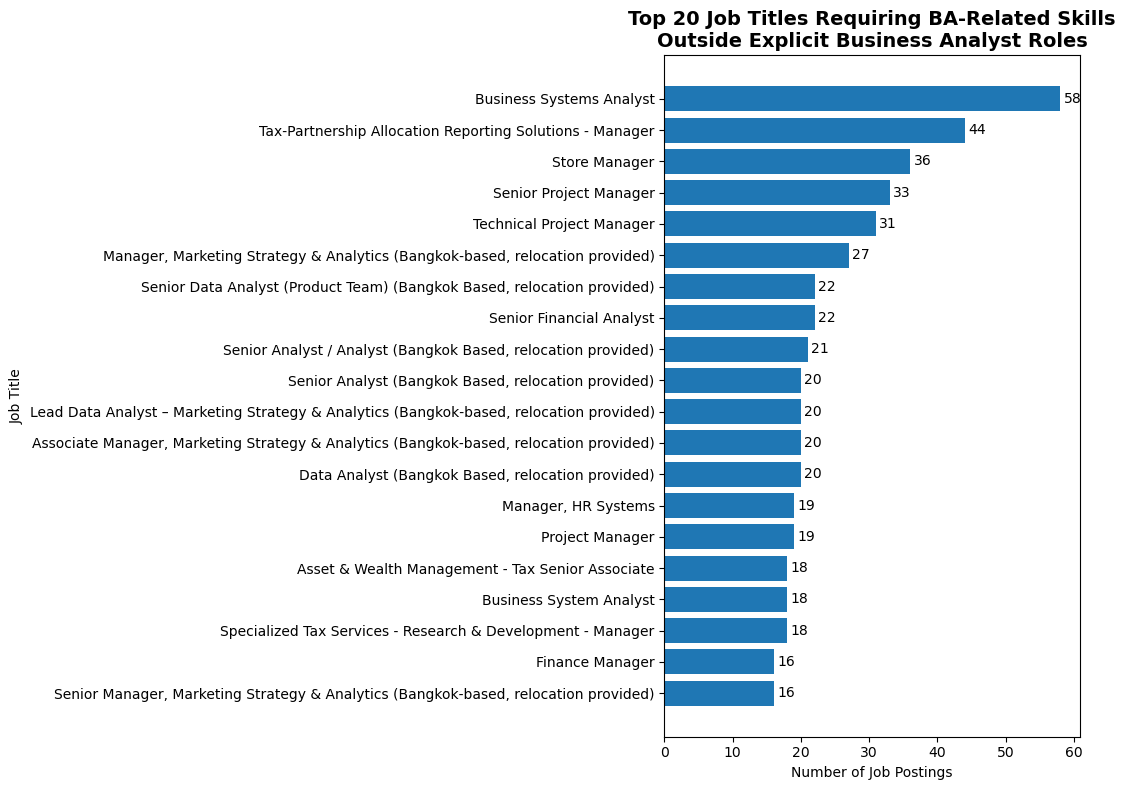

In [13]:
import matplotlib.pyplot as plt

top_titles = (
    skills_only_jobs["job_title"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_titles.index,
    top_titles.values
)

plt.title(
    "Top 20 Job Titles Requiring BA-Related Skills\nOutside Explicit Business Analyst Roles",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

postings_path = r"E:\Analytic Plan BI\LinkedIn Dataset\linkedin_job_postings.csv"

jobs_full = pd.read_csv(postings_path)

# Same reproducible BA definition used previously
ba_jobs = jobs_full[
    jobs_full["job_title"].str.contains(
        r"\bbusiness analyst\b",
        case=False,
        na=False,
        regex=True
    )
].copy()

print("Total explicit BA postings:", len(ba_jobs))
print("\nAvailable columns:")
print(ba_jobs.columns.tolist())

Total explicit BA postings: 4546

Available columns:
['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']


In [15]:
country_counts = ba_jobs["search_country"].value_counts(dropna=False)

country_percent = (
    ba_jobs["search_country"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

country_summary = pd.DataFrame({
    "Number of BA Jobs": country_counts,
    "Percentage (%)": country_percent
})

display(country_summary)

,Number of BA Jobs,Percentage (%)
search_country,,
United States,3732,82.09
United Kingdom,338,7.44
Canada,259,5.70
Australia,217,4.77


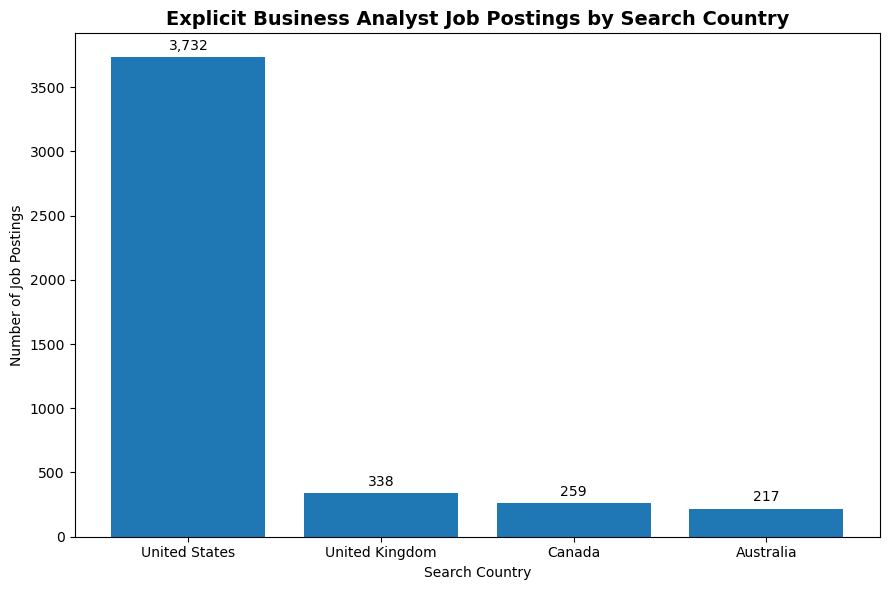

In [16]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    country_summary.index.astype(str),
    country_summary["Number of BA Jobs"]
)

plt.title(
    "Explicit Business Analyst Job Postings by Search Country",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Search Country")
plt.ylabel("Number of Job Postings")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(country_counts) * 0.01,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [17]:
display(
    ba_jobs[
        [
            "job_title",
            "job_location",
            "search_city",
            "search_country"
        ]
    ].sample(
        30,
        random_state=42
    )
)

,job_title,job_location,search_city,search_country
185866,Business Analyst - Permanent - Wigan/Manchester,"Wigan, England, United Kingdom",Liverpool,United Kingdom
1041229,Senior Business Analyst,"Boston, MA",Massachusetts,United States
12247,Business Analyst II,"Richland, WA",Kennewick,United States
611128,Business Analyst,"Lisle, IL",Homer,United States
56203,Business Analyst,"McLean, VA",Manassas,United States
562002,Technical Business Analyst-,"Ann Arbor, MI",Pittsfield,United States
874664,Business Analyst - Financial Reporting,"New York, NY",New York,United States
652662,Business Analyst(with payments experience in Banking domain),"New York, United States",Hamilton,United States
651672,JD Edwards Business Analyst,"Las Vegas, NV",Las Vegas,United States
844498,JD Edwards Business Analyst,"Indiana, United States",Guilford,United States


In [18]:
non_us_ba = ba_jobs[
    ba_jobs["search_country"]
    .astype(str)
    .str.lower()
    .ne("united states")
]

print("Non-US explicit BA postings:", len(non_us_ba))

display(
    non_us_ba[
        [
            "job_title",
            "company",
            "job_location",
            "search_city",
            "search_country"
        ]
    ].head(30)
)

Non-US explicit BA postings: 814


,job_title,company,job_location,search_city,search_country
6434,ICT Business Analyst,LVT People,"Millers Point, New South Wales, Australia",Parramatta,Australia
6711,Principal Business Analyst,Sysco Canada Inc.,"Peterborough, Ontario, Canada",Kawartha Lakes,Canada
13454,"Business Analyst I or II, OPL_fr",Intact,"Montreal, Quebec, Canada",Laval,Canada
22273,Business Analyst,Sparta Global,"Slough, England, United Kingdom",High Wycombe,United Kingdom
22298,Business Analyst,Localcoin,"Toronto, Ontario, Canada",Sarnia-Clearwater,Canada
28773,Senior Business Analyst,TEEMA,"Winnipeg, Manitoba, Canada",Manitoba,Canada
34168,Technical Business Analyst,Region 4 ESC,"Region 4, Northwest Territories, Canada",Delta,Canada
46470,Business Analyst,Peoplebank,"Parkes, New South Wales, Australia",Redcliffe,Australia
47822,Business Analyst - AX Replacement,Ignite Digital Talent,"London, England, United Kingdom",Greater London,United Kingdom
50900,Business Analyst,Taylor Wessing UK,"Liverpool, England, United Kingdom",Liverpool,United Kingdom


In [19]:
# Create US explicit Business Analyst dataset
us_ba_jobs = ba_jobs[
    ba_jobs["search_country"]
    .str.strip()
    .str.lower()
    .eq("united states")
].copy()

print("Total explicit BA postings:", len(ba_jobs))
print("US explicit BA postings:", len(us_ba_jobs))
print("Non-US explicit BA postings:", len(ba_jobs) - len(us_ba_jobs))

print(
    "US percentage:",
    round(len(us_ba_jobs) / len(ba_jobs) * 100, 2),
    "%"
)

Total explicit BA postings: 4546
US explicit BA postings: 3732
Non-US explicit BA postings: 814
US percentage: 82.09 %


In [20]:
print("Unique US BA job locations:",
      us_ba_jobs["job_location"].nunique())

print("\nMissing job locations:",
      us_ba_jobs["job_location"].isna().sum())

print("\nTop 30 advertised job locations:")

display(
    us_ba_jobs["job_location"]
    .value_counts(dropna=False)
    .head(30)
    .to_frame("Number of BA Jobs")
)

Unique US BA job locations: 862

Missing job locations: 0

Top 30 advertised job locations:


,Number of BA Jobs
job_location,
"New York, NY",102
"Boston, MA",86
"Atlanta, GA",85
"Chicago, IL",68
"Austin, TX",58
"Dallas, TX",57
"Richmond, VA",57
"Washington, DC",55
"Charlotte, NC",52


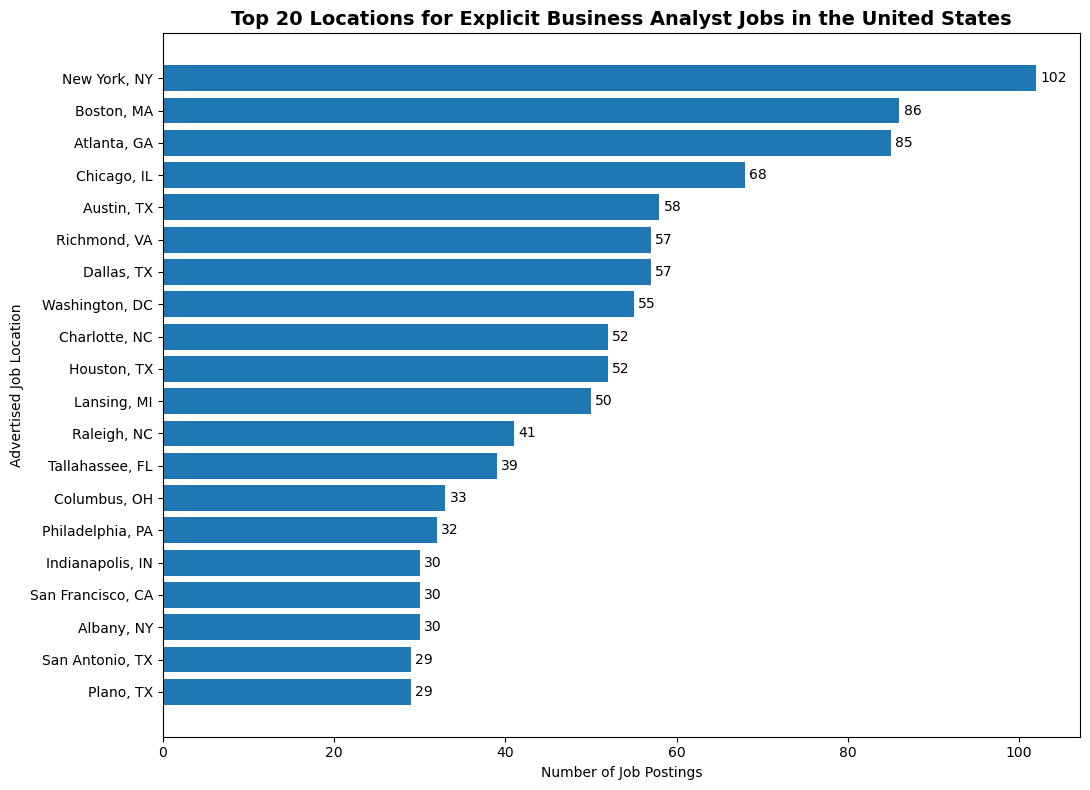

In [21]:
import matplotlib.pyplot as plt

top_locations = (
    us_ba_jobs["job_location"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_locations.index,
    top_locations.values
)

plt.title(
    "Top 20 Locations for Explicit Business Analyst Jobs in the United States",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Advertised Job Location")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [22]:
# Extract 2-letter state abbreviation from job_location
us_ba_jobs["state_code"] = (
    us_ba_jobs["job_location"]
    .str.extract(r",\s*([A-Z]{2})(?:\s|$)", expand=False)
)

print("US BA postings:", len(us_ba_jobs))

print(
    "Postings with state code extracted:",
    us_ba_jobs["state_code"].notna().sum()
)

print(
    "Postings where state could not be extracted:",
    us_ba_jobs["state_code"].isna().sum()
)

print("\nTop state codes:")
display(
    us_ba_jobs["state_code"]
    .value_counts()
    .head(30)
    .to_frame("Number of BA Jobs")
)

US BA postings: 3732
Postings with state code extracted: 3445
Postings where state could not be extracted: 287

Top state codes:


,Number of BA Jobs
state_code,
TX,318
CA,314
FL,272
NY,216
NJ,192
VA,178
MA,161
NC,149
GA,144


In [23]:
failed_state = us_ba_jobs[
    us_ba_jobs["state_code"].isna()
]

print("Unique unparsed locations:",
      failed_state["job_location"].nunique())

display(
    failed_state["job_location"]
    .value_counts(dropna=False)
    .head(50)
    .to_frame("Number of Jobs")
)

Unique unparsed locations: 78


,Number of Jobs
job_location,
"California, United States",21
"New York, United States",21
"Texas, United States",18
United States,14
"New Jersey, United States",13
"Maryland, United States",11
"Georgia, United States",11
"Ohio, United States",9
"Minnesota, United States",9


In [24]:
valid_state_codes = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE",
    "FL", "GA", "HI", "ID", "IL", "IN", "IA", "KS",
    "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS",
    "MO", "MT", "NE", "NV", "NH", "NJ", "NM", "NY",
    "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV",
    "WI", "WY", "DC"
}

invalid_codes = (
    us_ba_jobs.loc[
        us_ba_jobs["state_code"].notna() &
        ~us_ba_jobs["state_code"].isin(valid_state_codes),
        "state_code"
    ]
    .value_counts()
)

print("Invalid extracted codes:")
display(invalid_codes)

Invalid extracted codes:


Series([], Name: count, dtype: int64)

In [25]:
state_summary = (
    us_ba_jobs[
        us_ba_jobs["state_code"].isin(valid_state_codes)
    ]
    ["state_code"]
    .value_counts()
    .rename_axis("State")
    .reset_index(name="Number of BA Jobs")
)

state_summary["Percentage (%)"] = (
    state_summary["Number of BA Jobs"]
    / len(us_ba_jobs)
    * 100
).round(2)

display(state_summary.head(20))

,State,Number of BA Jobs,Percentage (%)
0,TX,318,8.52
1,CA,314,8.41
2,FL,272,7.29
3,NY,216,5.79
4,NJ,192,5.14
5,VA,178,4.77
6,MA,161,4.31
7,NC,149,3.99
8,GA,144,3.86
9,IL,142,3.80


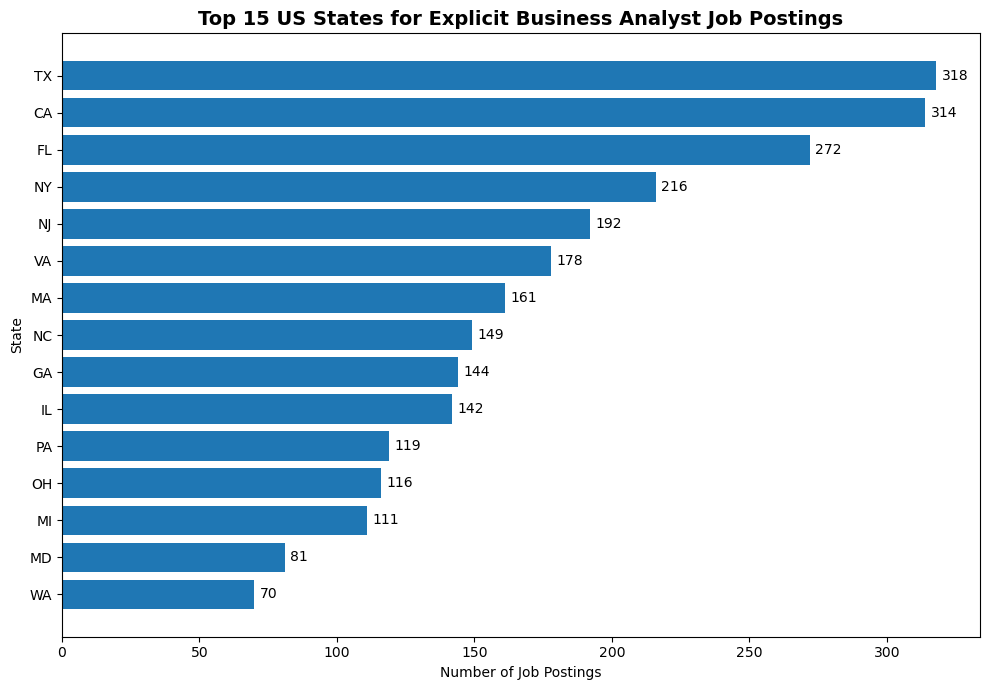

In [26]:
import matplotlib.pyplot as plt

top_states = (
    state_summary
    .head(15)
    .sort_values("Number of BA Jobs")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_states["State"],
    top_states["Number of BA Jobs"]
)

plt.title(
    "Top 15 US States for Explicit Business Analyst Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("State")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [27]:
state_name_to_code = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ",
    "Arkansas": "AR", "California": "CA", "Colorado": "CO",
    "Connecticut": "CT", "Delaware": "DE", "Florida": "FL",
    "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA",
    "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
    "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC"
}

# Preserve original extraction
us_ba_jobs["state_clean"] = us_ba_jobs["state_code"]

# For records that were not parsed, look for full state names
for state_name, state_code in state_name_to_code.items():
    mask = (
        us_ba_jobs["state_clean"].isna()
        & us_ba_jobs["job_location"]
            .astype(str)
            .str.contains(state_name, case=False, regex=False)
    )
    
    us_ba_jobs.loc[mask, "state_clean"] = state_code

print("Total US BA postings:", len(us_ba_jobs))
print("State identified:", us_ba_jobs["state_clean"].notna().sum())
print("Still unclassified:", us_ba_jobs["state_clean"].isna().sum())

print(
    "State classification rate:",
    round(us_ba_jobs["state_clean"].notna().mean() * 100, 2),
    "%"
)

display(
    us_ba_jobs.loc[
        us_ba_jobs["state_clean"].isna(),
        "job_location"
    ]
    .value_counts(dropna=False)
    .head(50)
    .to_frame("Number of Jobs")
)

Total US BA postings: 3732
State identified: 3677
Still unclassified: 55
State classification rate: 98.53 %


,Number of Jobs
job_location,
United States,14
"Vancouver, British Columbia, Canada",5
Utica-Rome Area,5
Los Angeles Metropolitan Area,3
Greater Phoenix Area,2
Greater Syracuse-Auburn Area,2
Greater Cleveland,2
Greater Reno Area,2
Greater Minneapolis-St. Paul Area,2


In [28]:
# Map remaining identifiable US metropolitan areas to states
metro_to_state = {
    "Utica-Rome Area": "NY",
    "Los Angeles Metropolitan Area": "CA",
    "Greater Phoenix Area": "AZ",
    "Greater Syracuse-Auburn Area": "NY",
    "Greater Cleveland": "OH",
    "Greater Reno Area": "NV",
    "Greater Minneapolis-St. Paul Area": "MN",
    "Buffalo-Niagara Falls Area": "NY",
    "Greater Orlando": "FL",
    "Greater Macon": "GA",
    "Greater Philadelphia": "PA",
    "Tallahassee Metropolitan Area": "FL",
    "Cincinnati Metropolitan Area": "OH",
    "Nashville Metropolitan Area": "TN",
    "Charlotte Metro": "NC",
    "Greater Anchorage Area": "AK",
    "San Francisco Bay Area": "CA",
    "Greater Tampa Bay Area": "FL",
    "Miami-Fort Lauderdale Area": "FL",
    "Dallas-Fort Worth Metroplex": "TX",
    "Brownsville Metropolitan Area": "TX",
    "Atlanta Metropolitan Area": "GA",
    "Greater Boston": "MA"
}

for location, state in metro_to_state.items():
    mask = (
        us_ba_jobs["state_clean"].isna()
        & us_ba_jobs["job_location"].eq(location)
    )
    us_ba_jobs.loc[mask, "state_clean"] = state


# Identify records whose advertised location conflicts
# with the US search_country classification
non_us_location_mask = (
    us_ba_jobs["job_location"]
    .astype(str)
    .str.contains(
        r"Canada|Mexico",
        case=False,
        na=False,
        regex=True
    )
)

us_ba_jobs["location_country_issue"] = non_us_location_mask

print("Total records:", len(us_ba_jobs))
print("State identified:", us_ba_jobs["state_clean"].notna().sum())
print("Still without state:", us_ba_jobs["state_clean"].isna().sum())

print(
    "Country inconsistencies:",
    us_ba_jobs["location_country_issue"].sum()
)

display(
    us_ba_jobs.loc[
        us_ba_jobs["state_clean"].isna(),
        ["job_location", "search_country"]
    ]
    .value_counts()
)

Total records: 3732
State identified: 3711
Still without state: 21
Country inconsistencies: 10


job_location                         search_country
United States                        United States     14
Vancouver, British Columbia, Canada  United States      5
Mexico City, Mexico                  United States      1
Mexico City Metropolitan Area        United States      1
Name: count, dtype: int64

In [29]:
# Map remaining identifiable US metropolitan areas to states
metro_to_state = {
    "Utica-Rome Area": "NY",
    "Los Angeles Metropolitan Area": "CA",
    "Greater Phoenix Area": "AZ",
    "Greater Syracuse-Auburn Area": "NY",
    "Greater Cleveland": "OH",
    "Greater Reno Area": "NV",
    "Greater Minneapolis-St. Paul Area": "MN",
    "Buffalo-Niagara Falls Area": "NY",
    "Greater Orlando": "FL",
    "Greater Macon": "GA",
    "Greater Philadelphia": "PA",
    "Tallahassee Metropolitan Area": "FL",
    "Cincinnati Metropolitan Area": "OH",
    "Nashville Metropolitan Area": "TN",
    "Charlotte Metro": "NC",
    "Greater Anchorage Area": "AK",
    "San Francisco Bay Area": "CA",
    "Greater Tampa Bay Area": "FL",
    "Miami-Fort Lauderdale Area": "FL",
    "Dallas-Fort Worth Metroplex": "TX",
    "Brownsville Metropolitan Area": "TX",
    "Atlanta Metropolitan Area": "GA",
    "Greater Boston": "MA"
}

for location, state in metro_to_state.items():
    mask = (
        us_ba_jobs["state_clean"].isna()
        & us_ba_jobs["job_location"].eq(location)
    )
    us_ba_jobs.loc[mask, "state_clean"] = state


# Identify records whose advertised location conflicts
# with the US search_country classification
non_us_location_mask = (
    us_ba_jobs["job_location"]
    .astype(str)
    .str.contains(
        r"Canada|Mexico",
        case=False,
        na=False,
        regex=True
    )
)

us_ba_jobs["location_country_issue"] = non_us_location_mask

print("Total records:", len(us_ba_jobs))
print("State identified:", us_ba_jobs["state_clean"].notna().sum())
print("Still without state:", us_ba_jobs["state_clean"].isna().sum())

print(
    "Country inconsistencies:",
    us_ba_jobs["location_country_issue"].sum()
)

display(
    us_ba_jobs.loc[
        us_ba_jobs["state_clean"].isna(),
        ["job_location", "search_country"]
    ]
    .value_counts()
)

Total records: 3732
State identified: 3711
Still without state: 21
Country inconsistencies: 10


job_location                         search_country
United States                        United States     14
Vancouver, British Columbia, Canada  United States      5
Mexico City, Mexico                  United States      1
Mexico City Metropolitan Area        United States      1
Name: count, dtype: int64

In [30]:
# Inspect all records flagged as country inconsistencies
display(
    us_ba_jobs.loc[
        us_ba_jobs["location_country_issue"],
        [
            "job_title",
            "job_location",
            "search_city",
            "search_country",
            "state_clean"
        ]
    ]
)

,job_title,job_location,search_city,search_country,state_clean
86757,Senior Business Analyst [BHJOB13022_12973],"Vancouver, British Columbia, Canada",Point Roberts,United States,NaN
414478,"BUSINESS ANALYST - DUBAI, UAE",Mexico City Metropolitan Area,Hollywood,United States,NaN
654398,Business Analyst(E-commerce),"Mexico City, Mexico",Hollywood,United States,NaN
830953,"Business Analyst, PMO","Tijuana, Baja California, Mexico",Chula Vista,United States,CA
905728,ISL 27R - Project Manager/Team Lead Business Analyst (BC Public Service),"Vancouver, British Columbia, Canada",Point Roberts,United States,NaN
996377,Senior Business Analyst,"Vancouver, British Columbia, Canada",Point Roberts,United States,NaN
1143824,Dynamics 365 CE Business Analyst (Remote) [NTT DATA],"Vancouver, British Columbia, Canada",Point Roberts,United States,NaN
1168932,Business Analyst - Regulatory Reporting,"Canada, KY",Kentucky,United States,KY
1274895,Global Enterprise Technology Business Analyst,"Mexicali, Baja California, Mexico",Calexico,United States,CA
1292528,Senior Business Analyst (Maximo),"Vancouver, British Columbia, Canada",Point Roberts,United States,NaN


In [31]:
print(
    us_ba_jobs.loc[
        us_ba_jobs["location_country_issue"],
        "job_location"
    ].value_counts()
)


job_location
Vancouver, British Columbia, Canada    5
Mexico City Metropolitan Area          1
Mexico City, Mexico                    1
Tijuana, Baja California, Mexico       1
Canada, KY                             1
Mexicali, Baja California, Mexico      1
Name: count, dtype: int64


In [32]:
# Remove advertised locations that conflict with US geography
us_ba_geo = us_ba_jobs[
    ~us_ba_jobs["location_country_issue"]
].copy()

print("Original search-country US records:", len(us_ba_jobs))
print("Country inconsistencies removed:", us_ba_jobs["location_country_issue"].sum())
print("Final US BA geography dataset:", len(us_ba_geo))

print("\nState identified:", us_ba_geo["state_clean"].notna().sum())
print("State unknown:", us_ba_geo["state_clean"].isna().sum())

print(
    "State coverage:",
    round(us_ba_geo["state_clean"].notna().mean() * 100, 2),
    "%"
)

Original search-country US records: 3732
Country inconsistencies removed: 10
Final US BA geography dataset: 3722

State identified: 3708
State unknown: 14
State coverage: 99.62 %


In [33]:
state_summary = (
    us_ba_geo
    .dropna(subset=["state_clean"])
    .groupby("state_clean")
    .size()
    .reset_index(name="BA_Postings")
    .sort_values("BA_Postings", ascending=False)
)

state_summary["Percentage"] = (
    state_summary["BA_Postings"]
    / state_summary["BA_Postings"].sum()
    * 100
).round(2)

display(state_summary.head(20))

print(
    "\nTotal postings represented in state analysis:",
    state_summary["BA_Postings"].sum()
)

,state_clean,BA_Postings,Percentage
42,TX,341,9.20
4,CA,339,9.14
9,FL,279,7.52
33,NY,255,6.88
30,NJ,205,5.53
44,VA,180,4.85
19,MA,165,4.45
26,NC,158,4.26
10,GA,157,4.23
14,IL,144,3.88



Total postings represented in state analysis: 3708


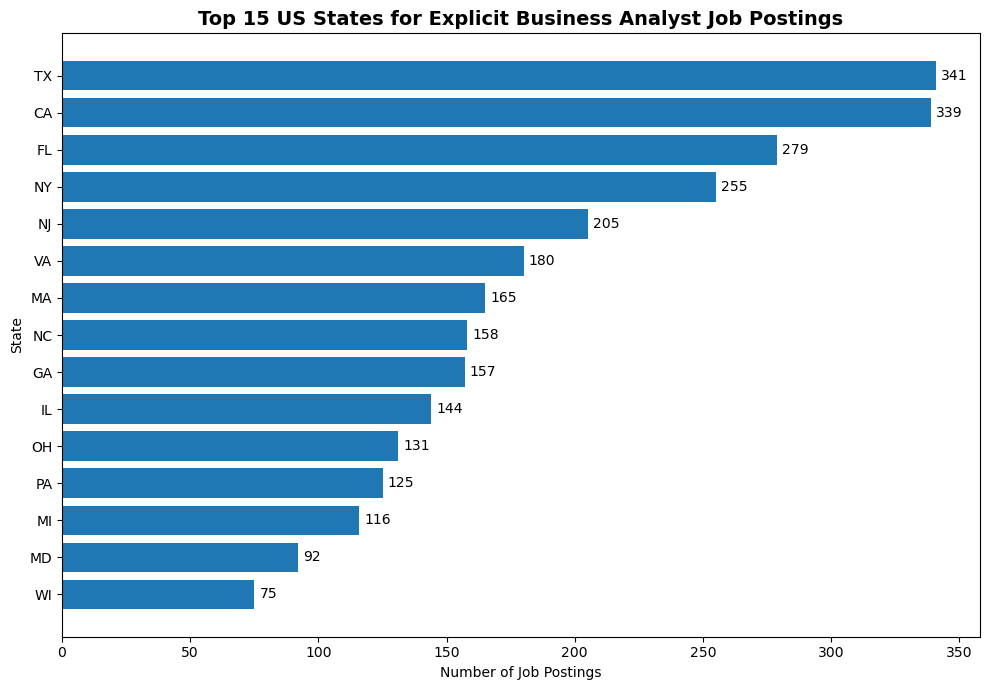

In [34]:
import matplotlib.pyplot as plt

top_states = state_summary.head(15).sort_values(
    "BA_Postings",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_states["state_clean"],
    top_states["BA_Postings"]
)

plt.title(
    "Top 15 US States for Explicit Business Analyst Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Job Postings")
plt.ylabel("State")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [35]:
# Create final state summary
state_summary = (
    us_ba_geo
    .dropna(subset=["state_clean"])
    .groupby("state_clean")
    .size()
    .reset_index(name="BA_Postings")
    .sort_values("BA_Postings", ascending=False)
)

# Calculate percentage of state-identifiable US BA postings
state_summary["Percentage (%)"] = (
    state_summary["BA_Postings"]
    / state_summary["BA_Postings"].sum()
    * 100
).round(2)

# Display top 20 states
display(state_summary.head(20))

# Validation
print(
    "Total postings represented in state analysis:",
    state_summary["BA_Postings"].sum()
)

print(
    "Number of states/territories represented:",
    state_summary["state_clean"].nunique()
)

,state_clean,BA_Postings,Percentage (%)
42,TX,341,9.20
4,CA,339,9.14
9,FL,279,7.52
33,NY,255,6.88
30,NJ,205,5.53
44,VA,180,4.85
19,MA,165,4.45
26,NC,158,4.26
10,GA,157,4.23
14,IL,144,3.88


Total postings represented in state analysis: 3708
Number of states/territories represented: 50


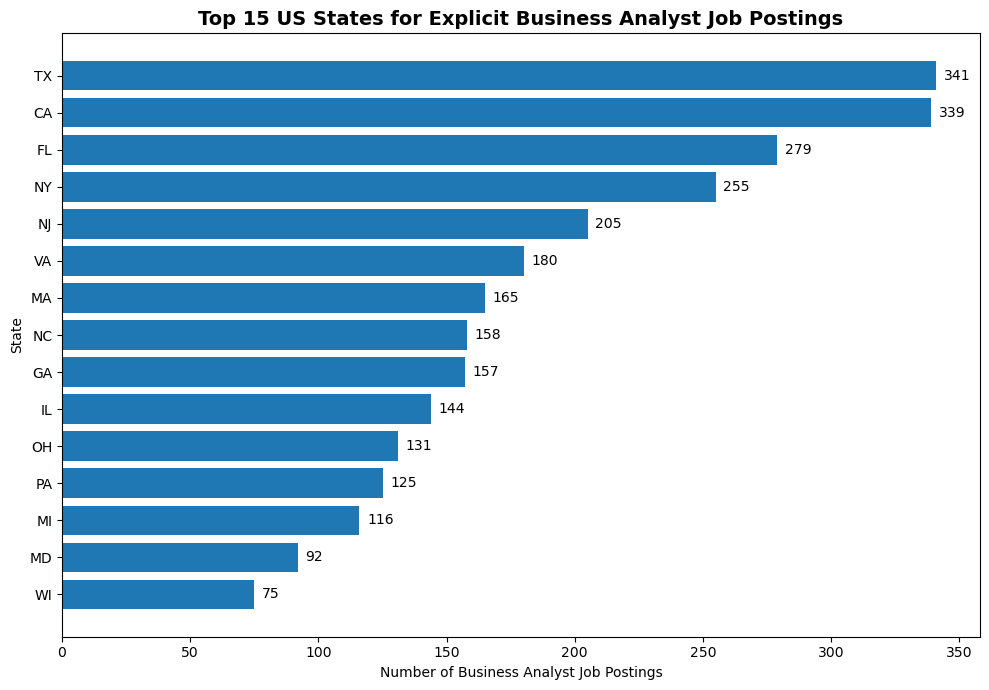

In [36]:
import matplotlib.pyplot as plt

# Select top 15 states
top_15_states = state_summary.head(15).copy()

# Reverse order for horizontal chart
top_15_states = top_15_states.sort_values(
    "BA_Postings",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_15_states["state_clean"],
    top_15_states["BA_Postings"]
)

plt.title(
    "Top 15 US States for Explicit Business Analyst Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Business Analyst Job Postings")
plt.ylabel("State")

# Add values to bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [37]:
print("Rows in cleaned US geography dataset:", len(us_ba_geo))
print("State not missing:", us_ba_geo["state_clean"].notna().sum())
print("State missing:", us_ba_geo["state_clean"].isna().sum())

display(
    us_ba_geo.loc[
        us_ba_geo["state_clean"].isna(),
        ["job_title", "job_location", "search_city", "search_country"]
    ]
)

Rows in cleaned US geography dataset: 3722
State not missing: 3708
State missing: 14


,job_title,job_location,search_city,search_country
54903,Public Sector Solutions Salesforce Business Analyst (Salesforce BA with PSS),United States,Smith Center,United States
204646,Business Analyst - 401k,United States,Smith Center,United States
320602,Business Analyst II - Encounter Operations,United States,Smith Center,United States
375294,Business Analyst -UAT Tester-Supply Chain Finance,United States,Smith Center,United States
400385,Business Analyst III,United States,Smith Center,United States
401137,Business Analyst,United States,Smith Center,United States
401351,Oracle Business Analyst,United States,Smith Center,United States
458812,Senior Business Analyst - SAP Logistics,United States,Smith Center,United States
459001,Business Analyst-II #: 23-06156,United States,Smith Center,United States
611255,Business Analyst,United States,Smith Center,United States


# Explore job_level

In [38]:
# Job level distribution for cleaned US BA postings

job_level_summary = (
    us_ba_geo["job_level"]
    .value_counts(dropna=False)
    .rename_axis("Job_Level")
    .reset_index(name="BA_Postings")
)

job_level_summary["Percentage (%)"] = (
    job_level_summary["BA_Postings"]
    / len(us_ba_geo)
    * 100
).round(2)

display(job_level_summary)

print("Total cleaned US BA postings:", len(us_ba_geo))
print("Unique job levels:", us_ba_geo["job_level"].nunique(dropna=False))
print("Missing job level:", us_ba_geo["job_level"].isna().sum())

,Job_Level,BA_Postings,Percentage (%)
0,Mid senior,3267,87.78
1,Associate,455,12.22


Total cleaned US BA postings: 3722
Unique job levels: 2
Missing job level: 0


# Explore job_type

In [39]:
# Job type distribution for cleaned US BA postings

job_type_summary = (
    us_ba_geo["job_type"]
    .value_counts(dropna=False)
    .rename_axis("Job_Type")
    .reset_index(name="BA_Postings")
)

job_type_summary["Percentage (%)"] = (
    job_type_summary["BA_Postings"]
    / len(us_ba_geo)
    * 100
).round(2)

display(job_type_summary)

print("Total cleaned US BA postings:", len(us_ba_geo))
print("Unique job types:", us_ba_geo["job_type"].nunique(dropna=False))
print("Missing job type:", us_ba_geo["job_type"].isna().sum())

,Job_Type,BA_Postings,Percentage (%)
0,Onsite,3721,99.97
1,Remote,1,0.03


Total cleaned US BA postings: 3722
Unique job types: 2
Missing job type: 0


In [40]:
# Compare job_level and job_type with the FULL LinkedIn dataset

print("=== FULL DATASET: JOB LEVEL ===")
display(
    df["job_level"]
    .value_counts(dropna=False)
    .to_frame("Postings")
)

print("\nJob level percentages:")
display(
    (df["job_level"]
     .value_counts(normalize=True, dropna=False)
     * 100)
    .round(2)
    .to_frame("Percentage (%)")
)


print("\n=== FULL DATASET: JOB TYPE ===")
display(
    df["job_type"]
    .value_counts(dropna=False)
    .to_frame("Postings")
)

print("\nJob type percentages:")
display(
    (df["job_type"]
     .value_counts(normalize=True, dropna=False)
     * 100)
    .round(2)
    .to_frame("Percentage (%)")
)

=== FULL DATASET: JOB LEVEL ===


NameError: name 'df' is not defined

In [41]:
# Show DataFrames currently loaded in memory
import pandas as pd

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)

RuntimeError: dictionary changed size during iteration

In [42]:
# Show all DataFrames currently loaded in memory

import pandas as pd

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)

chunk (96381, 2)
matched (611, 2)
ba_skill_candidates (9357, 2)
jobs (1348454, 2)
ba_results (6, 2)
ba_overlap (3, 2)
skills_only_jobs (5462, 2)
jobs_full (1348454, 14)
ba_jobs (4546, 14)
country_summary (4, 2)
non_us_ba (814, 14)
us_ba_jobs (3732, 17)
failed_state (287, 15)
state_summary (50, 3)
top_states (15, 3)
us_ba_geo (3722, 17)
top_15_states (15, 3)
job_level_summary (2, 3)
job_type_summary (2, 3)


In [43]:
# Compare job_level and job_type with the FULL LinkedIn dataset

print("=== FULL DATASET: JOB LEVEL ===")

display(
    jobs_full["job_level"]
    .value_counts(dropna=False)
    .to_frame("Postings")
)

print("\nJob level percentages:")

display(
    (jobs_full["job_level"]
     .value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentage (%)")
)


print("\n=== FULL DATASET: JOB TYPE ===")

display(
    jobs_full["job_type"]
    .value_counts(dropna=False)
    .to_frame("Postings")
)

print("\nJob type percentages:")

display(
    (jobs_full["job_type"]
     .value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentage (%)")
)

=== FULL DATASET: JOB LEVEL ===


,Postings
job_level,
Mid senior,1204445
Associate,144009



Job level percentages:


,Percentage (%)
job_level,
Mid senior,89.32
Associate,10.68



=== FULL DATASET: JOB TYPE ===


,Postings
job_type,
Onsite,1337633
Hybrid,6562
Remote,4259



Job type percentages:


,Percentage (%)
job_type,
Onsite,99.20
Hybrid,0.49
Remote,0.32


In [44]:
# Explore employers advertising explicit Business Analyst positions

company_summary = (
    us_ba_geo["company"]
    .value_counts(dropna=False)
    .rename_axis("Company")
    .reset_index(name="BA_Postings")
)

company_summary["Percentage (%)"] = (
    company_summary["BA_Postings"]
    / len(us_ba_geo)
    * 100
).round(2)

print("Total US BA postings:", len(us_ba_geo))
print("Unique employers:", us_ba_geo["company"].nunique())
print("Missing company:", us_ba_geo["company"].isna().sum())

display(company_summary.head(30))

Total US BA postings: 3722
Unique employers: 1356
Missing company: 0


,Company,BA_Postings,Percentage (%)
0,LATICRETE International,312,8.38
1,Dice,165,4.43
2,Tata Consultancy Services,68,1.83
3,Stellent IT,59,1.59
4,NR Consulting,58,1.56
5,Jobs for Humanity,44,1.18
6,Software Technology Inc.,40,1.07
7,Diverse Lynx,37,0.99
8,Robert Half,35,0.94
9,CERES Group,28,0.75


In [45]:
# Employer concentration

top_5 = company_summary.head(5)["BA_Postings"].sum()
top_10 = company_summary.head(10)["BA_Postings"].sum()
top_20 = company_summary.head(20)["BA_Postings"].sum()

print(
    "Top 5 employers:",
    top_5,
    f"({top_5 / len(us_ba_geo) * 100:.2f}%)"
)

print(
    "Top 10 employers:",
    top_10,
    f"({top_10 / len(us_ba_geo) * 100:.2f}%)"
)

print(
    "Top 20 employers:",
    top_20,
    f"({top_20 / len(us_ba_geo) * 100:.2f}%)"
)

Top 5 employers: 662 (17.79%)
Top 10 employers: 846 (22.73%)
Top 20 employers: 1090 (29.29%)


In [46]:
# Inspect LATICRETE Business Analyst postings

laticrete = us_ba_geo[
    us_ba_geo["company"].str.strip().str.casefold()
    == "laticrete international".casefold()
].copy()

print("Total LATICRETE BA postings:", len(laticrete))
print("Unique job links:", laticrete["job_link"].nunique())
print("Unique job titles:", laticrete["job_title"].nunique())
print("Unique locations:", laticrete["job_location"].nunique())

print("\nTop job titles:")
display(
    laticrete["job_title"]
    .value_counts()
    .head(20)
    .to_frame("Postings")
)

print("\nTop locations:")
display(
    laticrete["job_location"]
    .value_counts()
    .head(20)
    .to_frame("Postings")
)

Total LATICRETE BA postings: 312
Unique job links: 312
Unique job titles: 2
Unique locations: 131

Top job titles:


,Postings
job_title,
JDE Business Analyst (Supply Chain),163
JD Edwards Business Analyst,149



Top locations:


,Postings
job_location,
"California, United States",19
"Texas, United States",17
"Ohio, United States",6
"North Carolina, United States",6
"Columbus, OH",4
"Tennessee, United States",4
"South Carolina, United States",4
"Philadelphia, PA",4
"Minnesota, United States",4


In [47]:
# Check possible repeated/reposted vacancies

laticrete_duplicates = (
    laticrete
    .groupby(["company", "job_title", "job_location"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(laticrete_duplicates.head(30))

,company,job_title,job_location,Count
7,LATICRETE International,JD Edwards Business Analyst,"California, United States",11
237,LATICRETE International,JDE Business Analyst (Supply Chain),"Texas, United States",9
128,LATICRETE International,JDE Business Analyst (Supply Chain),"California, United States",8
107,LATICRETE International,JD Edwards Business Analyst,"Texas, United States",8
73,LATICRETE International,JD Edwards Business Analyst,"North Carolina, United States",3
75,LATICRETE International,JD Edwards Business Analyst,"Ohio, United States",3
202,LATICRETE International,JDE Business Analyst (Supply Chain),"Ohio, United States",3
200,LATICRETE International,JDE Business Analyst (Supply Chain),"North Carolina, United States",3
14,LATICRETE International,JD Edwards Business Analyst,"Colorado, United States",2
110,LATICRETE International,JD Edwards Business Analyst,Utica-Rome Area,2


In [48]:
display(
    laticrete[
        [
            "job_title",
            "job_location",
            "first_seen",
            "job_link"
        ]
    ]
    .sort_values(["job_title", "job_location", "first_seen"])
    .head(50)
)

,job_title,job_location,first_seen,job_link
1166544,JD Edwards Business Analyst,"Alabama, United States",2024-01-14,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660443880
1325638,JD Edwards Business Analyst,"Apollo Beach, FL",2024-01-14,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660443876
649227,JD Edwards Business Analyst,"Arkansas, United States",2024-01-13,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660444816
653690,JD Edwards Business Analyst,"Baltimore, MD",2024-01-13,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660448427
755391,JD Edwards Business Analyst,"Bethany, CT",2024-01-14,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660450145
857247,JD Edwards Business Analyst,"Bridge Creek, WI",2024-01-16,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660443882
145149,JD Edwards Business Analyst,"Brooklyn, NY",2024-01-13,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3660445586
61421,JD Edwards Business Analyst,"California, United States",2024-01-16,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3684706524
63436,JD Edwards Business Analyst,"California, United States",2024-01-16,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3685684825
122990,JD Edwards Business Analyst,"California, United States",2024-01-16,https://www.linkedin.com/jobs/view/jd-edwards-business-analyst-at-laticrete-international-3683785903


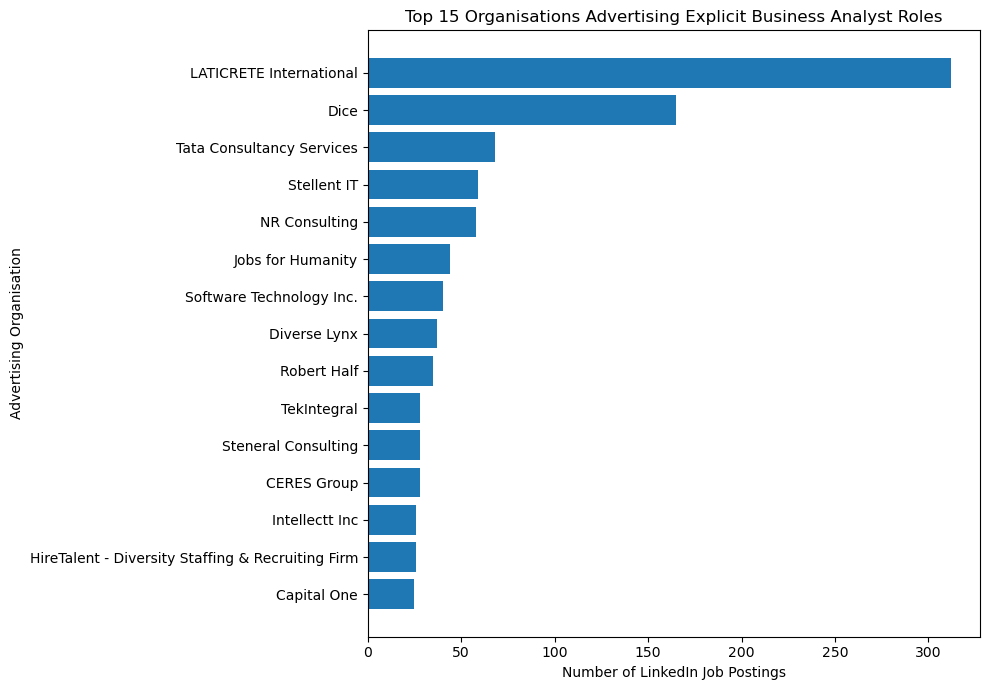

In [49]:
import matplotlib.pyplot as plt

top_15_companies = company_summary.head(15).sort_values(
    "BA_Postings",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15_companies["Company"],
    top_15_companies["BA_Postings"]
)

plt.xlabel("Number of LinkedIn Job Postings")
plt.ylabel("Advertising Organisation")
plt.title("Top 15 Organisations Advertising Explicit Business Analyst Roles")

plt.tight_layout()
plt.show()

In [50]:
print(jobs.columns)
print(jobs.shape)

display(jobs.head())

Index(['job_link', 'job_title'], dtype='object')
(1348454, 2)


,job_link,job_title
0,https://www.linkedin.com/jobs/view/account-executive-dispensing-norcal-northern-nevada-becton-dickinson-at-bd-3802078767,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson
1,https://www.linkedin.com/jobs/view/registered-nurse-rn-care-manager-at-trinity-health-mi-3803386312,Registered Nurse - RN Care Manager
2,https://www.linkedin.com/jobs/view/restaurant-supervisor-the-forklift-at-wasatch-adaptive-sports-3771464419,RESTAURANT SUPERVISOR - THE FORKLIFT
3,https://www.linkedin.com/jobs/view/independent-real-estate-agent-at-howard-hanna-rand-realty-3797661348,Independent Real Estate Agent
4,https://www.linkedin.com/jobs/view/group-unit-supervisor-systems-support-manager-tss-at-irs-office-of-chief-counsel-3803057508,Group/Unit Supervisor (Systems Support Manager TSS)


In [54]:
skills_path = r"E:\Analytic Plan BI\LinkedIn Dataset\job_skills.csv"

In [55]:
ba_links = set(us_ba_geo["job_link"])

matched_chunks = []

for chunk in pd.read_csv(
    skills_path,
    usecols=["job_link", "job_skills"],
    chunksize=100000
):
    matched = chunk[chunk["job_link"].isin(ba_links)]

    if not matched.empty:
        matched_chunks.append(matched)

us_ba_skills = pd.concat(matched_chunks, ignore_index=True)

print("Cleaned US BA postings:", len(us_ba_geo))
print("BA postings matched to skills file:", len(us_ba_skills))
print("Unique matched job links:", us_ba_skills["job_link"].nunique())
print("Missing job_skills:", us_ba_skills["job_skills"].isna().sum())

Cleaned US BA postings: 3722
BA postings matched to skills file: 3606
Unique matched job links: 3606
Missing job_skills: 0


In [56]:
# Create one row per job-skill combination
skills_long = (
    us_ba_skills
    .dropna(subset=["job_skills"])
    .assign(skill=us_ba_skills["job_skills"].str.split(","))
    .explode("skill")
)

# Clean skill text
skills_long["skill"] = skills_long["skill"].str.strip()

# Remove blank values
skills_long = skills_long[
    skills_long["skill"].notna() &
    (skills_long["skill"] != "")
].copy()

# Normalise case
skills_long["skill_clean"] = skills_long["skill"].str.casefold()

# Prevent the same skill being counted twice within one job
skills_long = skills_long.drop_duplicates(
    subset=["job_link", "skill_clean"]
)

print("BA postings with skills:", us_ba_skills["job_link"].nunique())
print("Total unique job-skill combinations:", len(skills_long))
print("Unique skill terms:", skills_long["skill_clean"].nunique())

display(skills_long.head(10))

BA postings with skills: 3606
Total unique job-skill combinations: 92020
Unique skill terms: 22196


,job_link,job_skills,skill,skill_clean
0,https://www.linkedin.com/jobs/view/business-analyst-4-lansing-mi-12%2B-months-contract-at-spanco-solutions-3801582777,"SQL Server, Power BI, Business Requirements Gathering, Risk Assessment, Project Management Methodology (PMM), Systems Engineering Methodology (SEM), Test data, Test results, Defect tracking, Problem resolution, RFCs, IT strategic direction/plan, Communication plan, Audit investigation, Security reviews, Disaster recovery planning, Technical leadership, System analysis, System design, System testing, Data communications, Data processing, Application development environments, Objectoriented ap...",SQL Server,sql server
0,https://www.linkedin.com/jobs/view/business-analyst-4-lansing-mi-12%2B-months-contract-at-spanco-solutions-3801582777,"SQL Server, Power BI, Business Requirements Gathering, Risk Assessment, Project Management Methodology (PMM), Systems Engineering Methodology (SEM), Test data, Test results, Defect tracking, Problem resolution, RFCs, IT strategic direction/plan, Communication plan, Audit investigation, Security reviews, Disaster recovery planning, Technical leadership, System analysis, System design, System testing, Data communications, Data processing, Application development environments, Objectoriented ap...",Power BI,power bi
0,https://www.linkedin.com/jobs/view/business-analyst-4-lansing-mi-12%2B-months-contract-at-spanco-solutions-3801582777,"SQL Server, Power BI, Business Requirements Gathering, Risk Assessment, Project Management Methodology (PMM), Systems Engineering Methodology (SEM), Test data, Test results, Defect tracking, Problem resolution, RFCs, IT strategic direction/plan, Communication plan, Audit investigation, Security reviews, Disaster recovery planning, Technical leadership, System analysis, System design, System testing, Data communications, Data processing, Application development environments, Objectoriented ap...",Business Requirements Gathering,business requirements gathering
0,https://www.linkedin.com/jobs/view/business-analyst-4-lansing-mi-12%2B-months-contract-at-spanco-solutions-3801582777,"SQL Server, Power BI, Business Requirements Gathering, Risk Assessment, Project Management Methodology (PMM), Systems Engineering Methodology (SEM), Test data, Test results, Defect tracking, Problem resolution, RFCs, IT strategic direction/plan, Communication plan, Audit investigation, Security reviews, Disaster recovery planning, Technical leadership, System analysis, System design, System testing, Data communications, Data processing, Application development environments, Objectoriented ap...",Risk Assessment,risk assessment
0,https://www.linkedin.com/jobs/view/business-analyst-4-lansing-mi-12%2B-months-contract-at-spanco-solutions-3801582777,"SQL Server, Power BI, Business Requirements Gathering, Risk Assessment, Project Management Methodology (PMM), Systems Engineering Methodology (SEM), Test data, Test results, Defect tracking, Problem resolution, RFCs, IT strategic direction/plan, Communication plan, Audit investigation, Security reviews, Disaster recovery planning, Technical leadership, System analysis, System design, System testing, Data communications, Data processing, Application development environments, Objectoriented ap...",Project Management Methodology (PMM),project management methodology (pmm)
0,https://www.linkedin.com/jobs/view/business-analyst-4-lansing-mi-12%2B-months-contract-at-spanco-solutions-3801582777,"SQL Server, Power BI, Business Requirements Gathering, Risk Assessment, Project Management Methodology (PMM), Systems Engineering Methodology (SEM), Test data, Test results, Defect tracking, Problem resolution, RFCs, IT strategic direction/plan, Communication plan, Audit investigation, Security reviews, Disaster recovery planning, Technical leadership, System analysis, System design, System testing, Data communications, Data processing, Application development environments, Objectoriented ap...",Systems Engineering

In [57]:
skill_summary = (
    skills_long
    .groupby("skill_clean")["job_link"]
    .nunique()
    .reset_index(name="Postings")
    .sort_values("Postings", ascending=False)
)

skill_summary["Percentage"] = (
    skill_summary["Postings"]
    / us_ba_skills["job_link"].nunique()
    * 100
).round(2)

display(skill_summary.head(30))

,skill_clean,Postings,Percentage
2952,business analysis,1475,40.90
15718,project management,1232,34.17
5712,data analysis,1214,33.67
4484,communication,1069,29.65
18650,sql,916,25.40
1562,analytical skills,750,20.80
15046,problem solving,599,16.61
4531,communication skills,591,16.39
16748,requirements gathering,576,15.97
19870,teamwork,574,15.92


In [58]:
# Conservative skill standardisation
skill_mapping = {
    "problemsolving": "problem solving",
}

skills_long["skill_standard"] = (
    skills_long["skill_clean"]
    .replace(skill_mapping)
)

# Prevent duplicated standardised skills within the same job
skills_standard = skills_long.drop_duplicates(
    subset=["job_link", "skill_standard"]
)

skill_summary_std = (
    skills_standard
    .groupby("skill_standard")["job_link"]
    .nunique()
    .reset_index(name="Postings")
    .sort_values("Postings", ascending=False)
)

skill_summary_std["Percentage"] = (
    skill_summary_std["Postings"]
    / us_ba_skills["job_link"].nunique()
    * 100
).round(2)

display(skill_summary_std.head(30))

,skill_standard,Postings,Percentage
2952,business analysis,1475,40.90
15717,project management,1232,34.17
5712,data analysis,1214,33.67
4484,communication,1069,29.65
15046,problem solving,974,27.01
18649,sql,916,25.40
1562,analytical skills,750,20.80
4531,communication skills,591,16.39
16747,requirements gathering,576,15.97
19869,teamwork,574,15.92


In [59]:
# Exclude terms that are not useful for the skills-demand chart
exclude_terms = [
    "business analyst",
    "bachelor's degree",
    "computer science"
]

top_skills_chart = (
    skill_summary_std[
        ~skill_summary_std["skill_standard"].isin(exclude_terms)
    ]
    .head(15)
    .sort_values("Percentage", ascending=True)
)

display(top_skills_chart)

,skill_standard,Postings,Percentage
4342,collaboration,361,10.01
7973,excel,368,10.21
11354,jira,369,10.23
6945,documentation,375,10.40
1216,agile,523,14.50
19869,teamwork,574,15.92
16747,requirements gathering,576,15.97
4531,communication skills,591,16.39
1562,analytical skills,750,20.80
18649,sql,916,25.40


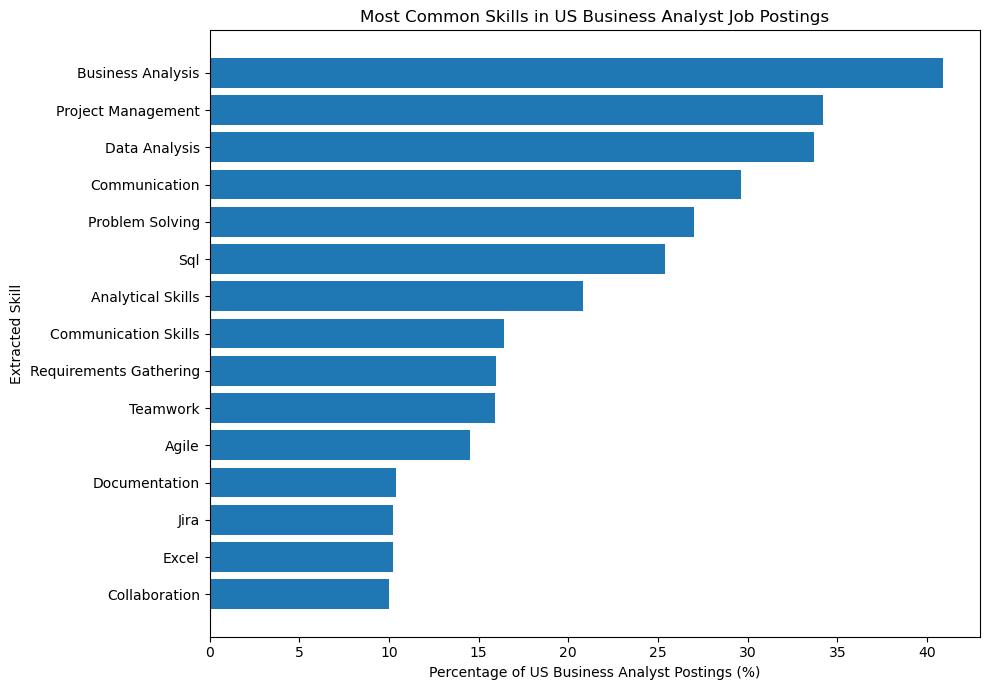

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.barh(
    top_skills_chart["skill_standard"].str.title(),
    top_skills_chart["Percentage"]
)

plt.xlabel("Percentage of US Business Analyst Postings (%)")
plt.ylabel("Extracted Skill")
plt.title("Most Common Skills in US Business Analyst Job Postings")

plt.tight_layout()
plt.show()

In [61]:
# All postings retrieved under the US search context
all_us_jobs = jobs_full[
    jobs_full["search_country"].eq("United States")
].copy()

ba_links = set(us_ba_geo["job_link"])

non_ba_us = all_us_jobs[
    ~all_us_jobs["job_link"].isin(ba_links)
].copy()

print("All US-search postings:", len(all_us_jobs))
print("Cleaned US explicit BA postings:", len(us_ba_geo))
print("Non-BA US comparison postings:", len(non_ba_us))

All US-search postings: 1149342
Cleaned US explicit BA postings: 3722
Non-BA US comparison postings: 1145620


In [62]:
selected_skills = [
    "business analysis",
    "project management",
    "data analysis",
    "communication",
    "problem solving",
    "sql",
    "analytical skills",
    "requirements gathering",
    "teamwork",
    "agile",
    "documentation",
    "jira",
    "excel",
    "testing",
    "stakeholder management",
    "user stories",
    "data visualization",
    "business requirements",
    "tableau",
    "functional specifications"
]

In [63]:
non_ba_links = set(non_ba_us["job_link"])

comparison_chunks = []

for chunk in pd.read_csv(
    skills_path,
    usecols=["job_link", "job_skills"],
    chunksize=100000
):
    matched = chunk[chunk["job_link"].isin(non_ba_links)]

    if not matched.empty:
        comparison_chunks.append(matched)

non_ba_skills = pd.concat(
    comparison_chunks,
    ignore_index=True
)

print("Non-BA US postings:", len(non_ba_us))
print("Matched to skills dataset:", len(non_ba_skills))
print(
    "Unique matched job links:",
    non_ba_skills["job_link"].nunique()
)
print(
    "Missing job_skills:",
    non_ba_skills["job_skills"].isna().sum()
)

coverage = (
    non_ba_skills["job_link"].nunique()
    / len(non_ba_us)
    * 100
)

print(f"Skills match rate: {coverage:.2f}%")

Non-BA US postings: 1145620
Matched to skills dataset: 1101804
Unique matched job links: 1101804
Missing job_skills: 1799
Skills match rate: 96.18%


In [69]:
import gc

for var in ["non_ba_long"]:
    if var in globals():
        del globals()[var]

gc.collect()

1580

In [70]:
# Selected skills
selected_skills = [
    "business analysis",
    "project management",
    "data analysis",
    "communication",
    "problem solving",
    "sql",
    "analytical skills",
    "requirements gathering",
    "teamwork",
    "agile",
    "documentation",
    "jira",
    "excel",
    "testing",
    "stakeholder management",
    "user stories",
    "data visualization",
    "business requirements",
    "tableau",
    "functional specifications"
]

# Only postings with usable skill information
non_ba_valid = non_ba_skills[
    non_ba_skills["job_skills"].notna()
].copy()

non_ba_denominator = non_ba_valid["job_link"].nunique()

print("Non-BA denominator:", non_ba_denominator)

Non-BA denominator: 1100005


In [71]:

non_ba_counts = {}

# Lowercase one column rather than exploding millions of skills
skill_text = non_ba_valid["job_skills"].str.lower()

for skill in selected_skills:

    if skill == "problem solving":
        # Combine the two formatting variants
        mask = (
            skill_text.str.contains(
                "problem solving",
                regex=False,
                na=False
            )
            |
            skill_text.str.contains(
                "problemsolving",
                regex=False,
                na=False
            )
        )
    else:
        mask = skill_text.str.contains(
            skill,
            regex=False,
            na=False
        )

    non_ba_counts[skill] = mask.sum()

print(non_ba_counts)

{'business analysis': np.int64(4179), 'project management': np.int64(105095), 'data analysis': np.int64(72875), 'communication': np.int64(607719), 'problem solving': np.int64(279200), 'sql': np.int64(25337), 'analytical skills': np.int64(51290), 'requirements gathering': np.int64(2819), 'teamwork': np.int64(205587), 'agile': np.int64(22443), 'documentation': np.int64(85619), 'jira': np.int64(6225), 'excel': np.int64(117797), 'testing': np.int64(52190), 'stakeholder management': np.int64(4527), 'user stories': np.int64(641), 'data visualization': np.int64(7413), 'business requirements': np.int64(1884), 'tableau': np.int64(5956), 'functional specifications': np.int64(398)}


In [72]:
ba_denominator = 3606

comparison_rows = []

for skill in selected_skills:

    ba_count = skills_standard.loc[
        skills_standard["skill_standard"] == skill,
        "job_link"
    ].nunique()

    non_ba_count = non_ba_counts[skill]

    ba_pct = ba_count / ba_denominator * 100
    non_ba_pct = non_ba_count / non_ba_denominator * 100

    prevalence_ratio = (
        ba_pct / non_ba_pct
        if non_ba_pct > 0
        else float("nan")
    )

    comparison_rows.append({
        "Skill": skill,
        "BA_Postings": ba_count,
        "BA_Percentage": ba_pct,
        "Non_BA_Postings": non_ba_count,
        "Non_BA_Percentage": non_ba_pct,
        "Prevalence_Ratio": prevalence_ratio,
        "Percentage_Point_Difference": ba_pct - non_ba_pct
    })

skill_comparison = pd.DataFrame(comparison_rows)

skill_comparison = skill_comparison.sort_values(
    "Prevalence_Ratio",
    ascending=False
)

# Round only for display
display(
    skill_comparison.round({
        "BA_Percentage": 2,
        "Non_BA_Percentage": 2,
        "Prevalence_Ratio": 2,
        "Percentage_Point_Difference": 2
    })
)

,Skill,BA_Postings,BA_Percentage,Non_BA_Postings,Non_BA_Percentage,Prevalence_Ratio,Percentage_Point_Difference
19,functional specifications,264,7.32,398,0.04,202.34,7.28
15,user stories,291,8.07,641,0.06,138.49,8.01
0,business analysis,1475,40.90,4179,0.38,107.67,40.52
7,requirements gathering,576,15.97,2819,0.26,62.33,15.72
17,business requirements,269,7.46,1884,0.17,43.56,7.29
14,stakeholder management,291,8.07,4527,0.41,19.61,7.66
11,jira,369,10.23,6225,0.57,18.08,9.67
18,tableau,268,7.43,5956,0.54,13.73,6.89
16,data visualization,277,7.68,7413,0.67,11.40,7.01
5,sql,916,25.40,25337,2.30,11.03,23.10


In [73]:
# Function to standardise the skills within one posting
def get_standard_skills(skill_string):
    if pd.isna(skill_string):
        return set()

    skills = {
        skill.strip().casefold()
        for skill in skill_string.split(",")
        if skill.strip()
    }

    # Same conservative standardisation used earlier
    if "problemsolving" in skills:
        skills.discard("problemsolving")
        skills.add("problem solving")

    return skills


# Count selected skills
exact_non_ba_counts = {skill: 0 for skill in selected_skills}

for skill_string in non_ba_skills_valid["job_skills"]:

    job_skill_set = get_standard_skills(skill_string)

    for skill in selected_skills:
        if skill in job_skill_set:
            exact_non_ba_counts[skill] += 1

print(exact_non_ba_counts)

{'business analysis': 3991, 'project management': 95330, 'data analysis': 66906, 'communication': 309163, 'problem solving': 229951, 'sql': 17650, 'analytical skills': 48656, 'requirements gathering': 2248, 'teamwork': 192084, 'agile': 8929, 'documentation': 47367, 'jira': 5568, 'excel': 34616, 'testing': 8103, 'stakeholder management': 4308, 'user stories': 594, 'data visualization': 6645, 'business requirements': 1176, 'tableau': 5568, 'functional specifications': 361}


In [74]:
comparison_rows = []

ba_denominator = 3606
non_ba_denominator = 1100005

for skill in selected_skills:

    ba_count = skills_standard.loc[
        skills_standard["skill_standard"] == skill,
        "job_link"
    ].nunique()

    non_ba_count = exact_non_ba_counts[skill]

    ba_pct = ba_count / ba_denominator * 100
    non_ba_pct = non_ba_count / non_ba_denominator * 100

    prevalence_ratio = (
        ba_pct / non_ba_pct
        if non_ba_pct > 0
        else float("nan")
    )

    comparison_rows.append({
        "Skill": skill,
        "BA_Postings": ba_count,
        "BA_Percentage": ba_pct,
        "Non_BA_Postings": non_ba_count,
        "Non_BA_Percentage": non_ba_pct,
        "Prevalence_Ratio": prevalence_ratio,
        "Percentage_Point_Difference": ba_pct - non_ba_pct
    })

skill_comparison_exact = pd.DataFrame(comparison_rows)

skill_comparison_exact = skill_comparison_exact.sort_values(
    "Prevalence_Ratio",
    ascending=False
)

display(
    skill_comparison_exact.round({
        "BA_Percentage": 2,
        "Non_BA_Percentage": 2,
        "Prevalence_Ratio": 2,
        "Percentage_Point_Difference": 2
    })
)

,Skill,BA_Postings,BA_Percentage,Non_BA_Postings,Non_BA_Percentage,Prevalence_Ratio,Percentage_Point_Difference
19,functional specifications,264,7.32,361,0.03,223.08,7.29
15,user stories,291,8.07,594,0.05,149.44,8.02
0,business analysis,1475,40.90,3991,0.36,112.74,40.54
7,requirements gathering,576,15.97,2248,0.20,78.16,15.77
17,business requirements,269,7.46,1176,0.11,69.78,7.35
14,stakeholder management,291,8.07,4308,0.39,20.61,7.68
11,jira,369,10.23,5568,0.51,20.22,9.73
9,agile,523,14.50,8929,0.81,17.87,13.69
5,sql,916,25.40,17650,1.60,15.83,23.80
18,tableau,268,7.43,5568,0.51,14.68,6.93


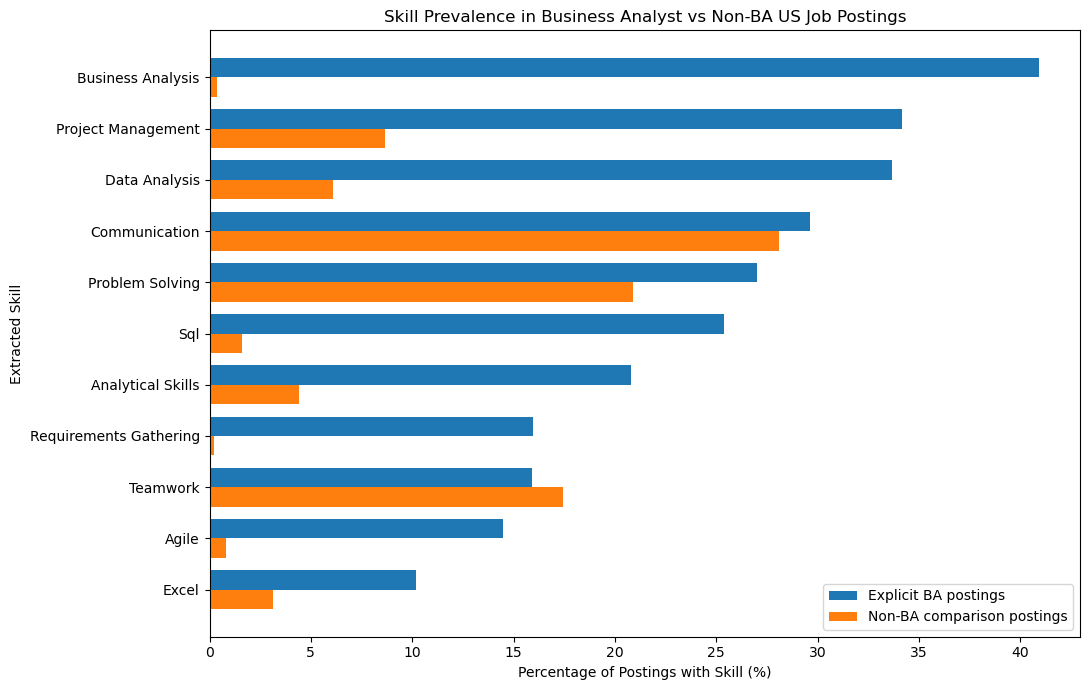

In [75]:
import matplotlib.pyplot as plt
import numpy as np

comparison_skills = [
    "business analysis",
    "requirements gathering",
    "sql",
    "agile",
    "data analysis",
    "project management",
    "analytical skills",
    "excel",
    "problem solving",
    "communication",
    "teamwork"
]

chart_data = skill_comparison_exact[
    skill_comparison_exact["Skill"].isin(comparison_skills)
].copy()

# Sort by BA prevalence
chart_data = chart_data.sort_values(
    "BA_Percentage",
    ascending=True
)

y = np.arange(len(chart_data))
height = 0.38

plt.figure(figsize=(11, 7))

plt.barh(
    y + height/2,
    chart_data["BA_Percentage"],
    height,
    label="Explicit BA postings"
)

plt.barh(
    y - height/2,
    chart_data["Non_BA_Percentage"],
    height,
    label="Non-BA comparison postings"
)

plt.yticks(
    y,
    chart_data["Skill"].str.title()
)

plt.xlabel("Percentage of Postings with Skill (%)")
plt.ylabel("Extracted Skill")
plt.title("Skill Prevalence in Business Analyst vs Non-BA US Job Postings")
plt.legend()

plt.tight_layout()
plt.show()

In [76]:
dq_completeness = pd.DataFrame({
    "Variable": jobs_full.columns,
    "Missing_Count": jobs_full.isna().sum().values,
    "Missing_Percentage": (
        jobs_full.isna().sum().values
        / len(jobs_full)
        * 100
    )
})

dq_completeness["Complete_Percentage"] = (
    100 - dq_completeness["Missing_Percentage"]
)

dq_completeness = dq_completeness.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(
    dq_completeness.round({
        "Missing_Percentage": 4,
        "Complete_Percentage": 4
    })
)

,Variable,Missing_Count,Missing_Percentage,Complete_Percentage
7,job_location,19,0.0014,99.9986
6,company,11,0.0008,99.9992
2,got_summary,0,0.0000,100.0000
3,got_ner,0,0.0000,100.0000
0,job_link,0,0.0000,100.0000
1,last_processed_time,0,0.0000,100.0000
5,job_title,0,0.0000,100.0000
4,is_being_worked,0,0.0000,100.0000
8,first_seen,0,0.0000,100.0000
9,search_city,0,0.0000,100.0000


In [77]:
print("Total rows:", len(jobs_full))

print(
    "Unique job links:",
    jobs_full["job_link"].nunique()
)

print(
    "Duplicate job links:",
    jobs_full["job_link"].duplicated().sum()
)

print(
    "Exact duplicate rows:",
    jobs_full.duplicated().sum()
)

print(
    "Unique job titles:",
    jobs_full["job_title"].nunique()
)

print(
    "Unique companies:",
    jobs_full["company"].nunique()
)

print(
    "Unique job locations:",
    jobs_full["job_location"].nunique()
)

Total rows: 1348454
Unique job links: 1348454
Duplicate job links: 0
Exact duplicate rows: 0
Unique job titles: 584544
Unique companies: 90605
Unique job locations: 29153


In [78]:
categorical_columns = [
    "got_summary",
    "got_ner",
    "is_being_worked",
    "search_country",
    "job_level",
    "job_type"
]

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print("=" * 50)

    print(
        jobs_full[col]
        .value_counts(dropna=False)
    )


got_summary
got_summary
t    1297877
f      50577
Name: count, dtype: int64

got_ner
got_ner
t    1296401
f      52053
Name: count, dtype: int64

is_being_worked
is_being_worked
f    1346978
t       1476
Name: count, dtype: int64

search_country
search_country
United States     1149342
United Kingdom     113421
Canada              55972
Australia           29719
Name: count, dtype: int64

job_level
job_level
Mid senior    1204445
Associate      144009
Name: count, dtype: int64

job_type
job_type
Onsite    1337633
Hybrid       6562
Remote       4259
Name: count, dtype: int64


In [79]:
print("first_seen sample:")
display(jobs_full["first_seen"].head())

print("\nlast_processed_time sample:")
display(jobs_full["last_processed_time"].head())

print("\nData types:")
print(
    jobs_full[
        ["first_seen", "last_processed_time"]
    ].dtypes
)

first_seen sample:


0    2024-01-15
1    2024-01-14
2    2024-01-14
3    2024-01-16
4    2024-01-17
Name: first_seen, dtype: object


last_processed_time sample:


0     2024-01-21 07:12:29.00256+00
1     2024-01-21 07:39:58.88137+00
2    2024-01-21 07:40:00.251126+00
3    2024-01-21 07:40:00.308133+00
4    2024-01-19 09:45:09.215838+00
Name: last_processed_time, dtype: object


Data types:
first_seen             object
last_processed_time    object
dtype: object


In [80]:
# Parse dates without changing the original columns
first_seen_dt = pd.to_datetime(
    jobs_full["first_seen"],
    errors="coerce"
)

processed_dt = pd.to_datetime(
    jobs_full["last_processed_time"],
    errors="coerce",
    utc=True
)

print("FIRST SEEN")
print("Earliest:", first_seen_dt.min())
print("Latest:", first_seen_dt.max())
print("Invalid/unparseable:", first_seen_dt.isna().sum())

print("\nLAST PROCESSED")
print("Earliest:", processed_dt.min())
print("Latest:", processed_dt.max())
print("Invalid/unparseable:", processed_dt.isna().sum())

FIRST SEEN
Earliest: 2024-01-12 00:00:00
Latest: 2024-01-17 00:00:00
Invalid/unparseable: 0

LAST PROCESSED
Earliest: 2024-01-19 09:45:09.215838+00:00
Latest: 2024-01-21 17:37:21.080491+00:00
Invalid/unparseable: 1


In [81]:
first_seen_year = first_seen_dt.dt.year
first_seen_month = first_seen_dt.dt.to_period("M")

print("Year distribution:")
print(first_seen_year.value_counts().sort_index())

print("\nMonthly distribution:")
print(first_seen_month.value_counts().sort_index())

Year distribution:
first_seen
2024    1348454
Name: count, dtype: int64

Monthly distribution:
first_seen
2024-01    1348454
Freq: M, Name: count, dtype: int64


In [82]:
for col in [
    "got_summary",
    "got_ner",
    "is_being_worked",
    "search_country",
    "job_level",
    "job_type"
]:
    summary = pd.DataFrame({
        "Count": jobs_full[col].value_counts(dropna=False),
        "Percentage": (
            jobs_full[col]
            .value_counts(dropna=False, normalize=True)
            * 100
        ).round(2)
    })

    print(f"\n--- {col} ---")
    display(summary)


--- got_summary ---


,Count,Percentage
got_summary,,
t,1297877,96.25
f,50577,3.75



--- got_ner ---


,Count,Percentage
got_ner,,
t,1296401,96.14
f,52053,3.86



--- is_being_worked ---


...

,Count,Percentage
search_country,,
United States,1149342,85.23
United Kingdom,113421,8.41
Canada,55972,4.15
Australia,29719,2.20



--- job_level ---


,Count,Percentage
job_level,,
Mid senior,1204445,89.32
Associate,144009,10.68



--- job_type ---


,Count,Percentage
job_type,,
Onsite,1337633,99.20
Hybrid,6562,0.49
Remote,4259,0.32


In [83]:
variables_used = [
    "job_link",
    "job_title",
    "company",
    "job_location",
    "search_country",
    "job_level",
    "job_type",
    "first_seen"
]

variable_dq = []

for col in variables_used:
    variable_dq.append({
        "Variable": col,
        "Total_Records": len(jobs_full),
        "Missing": jobs_full[col].isna().sum(),
        "Missing_%": jobs_full[col].isna().mean() * 100,
        "Unique_Values": jobs_full[col].nunique(dropna=True),
        "Unique_%": (
            jobs_full[col].nunique(dropna=True)
            / len(jobs_full)
            * 100
        )
    })

variable_dq = pd.DataFrame(variable_dq)

display(
    variable_dq.round({
        "Missing_%": 4,
        "Unique_%": 2
    })
)

,Variable,Total_Records,Missing,Missing_%,Unique_Values,Unique_%
0,job_link,1348454,0,0.0000,1348454,100.00
1,job_title,1348454,0,0.0000,584544,43.35
2,company,1348454,11,0.0008,90605,6.72
3,job_location,1348454,19,0.0014,29153,2.16
4,search_country,1348454,0,0.0000,4,0.00
5,job_level,1348454,0,0.0000,2,0.00
6,job_type,1348454,0,0.0000,3,0.00
7,first_seen,1348454,0,0.0000,6,0.00


In [84]:
invalid_processed = jobs_full[
    processed_dt.isna()
][
    ["job_link", "last_processed_time", "job_title"]
]

display(invalid_processed)

,job_link,last_processed_time,job_title
1184304,https://www.linkedin.com/jobs/view/registered-nurse-rn-case-manager-%242500-sign-on-bonus-at-lifespark-3802905818,2024-01-20 14:25:11+00,Registered Nurse - RN Case Manager- $2500 Sign On Bonus


In [85]:
import pandas as pd

# ---------------------------------------------------------
# DATA DICTIONARY - VARIABLES USED IN OUR ANALYSIS
# ---------------------------------------------------------

variables_used = [

    # =====================================================
    # ORIGINAL: linkedin_job_postings.csv
    # =====================================================

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "job_link",
        "Type": "Original",
        "Data_Type": "String",
        "Description": "Unique LinkedIn URL identifying each job posting.",
        "Role_in_Analysis": "Primary identifier and join key between datasets."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "job_title",
        "Type": "Original",
        "Data_Type": "String",
        "Description": "Advertised title of the job posting.",
        "Role_in_Analysis": "Used to identify explicit Business Analyst job postings."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "company",
        "Type": "Original",
        "Data_Type": "String",
        "Description": "Organisation associated with the job advertisement.",
        "Role_in_Analysis": "Used to analyse organisations advertising Business Analyst roles."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "job_location",
        "Type": "Original",
        "Data_Type": "String",
        "Description": "Advertised geographic location of the job.",
        "Role_in_Analysis": "Used to determine and standardise the actual advertised US location."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "search_country",
        "Type": "Original",
        "Data_Type": "Categorical",
        "Description": "Country used in the LinkedIn search/retrieval context.",
        "Role_in_Analysis": "Used for initial US filtering before validating against job_location."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "search_city",
        "Type": "Original",
        "Data_Type": "Categorical",
        "Description": "City associated with the LinkedIn search context.",
        "Role_in_Analysis": "Used during geographic validation and investigation of location inconsistencies."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "search_position",
        "Type": "Original",
        "Data_Type": "Categorical",
        "Description": "Position/search category associated with collection of the posting.",
        "Role_in_Analysis": "Explored to determine whether it represented the advertised occupation; found not to be equivalent to job_title."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "job_level",
        "Type": "Original",
        "Data_Type": "Categorical",
        "Description": "Job seniority classification provided in the dataset.",
        "Role_in_Analysis": "Explored to examine seniority characteristics of BA postings."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "job_type",
        "Type": "Original",
        "Data_Type": "Categorical",
        "Description": "Work-arrangement classification such as Onsite, Hybrid or Remote.",
        "Role_in_Analysis": "Explored to examine work-arrangement characteristics."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "first_seen",
        "Type": "Original",
        "Data_Type": "Date",
        "Description": "Date on which the posting was first observed in the dataset.",
        "Role_in_Analysis": "Used to evaluate temporal coverage and timeliness."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "last_processed_time",
        "Type": "Original",
        "Data_Type": "Datetime",
        "Description": "Timestamp showing when the posting was last processed.",
        "Role_in_Analysis": "Used to assess temporal coverage and timestamp consistency."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "got_summary",
        "Type": "Original",
        "Data_Type": "Boolean/Categorical",
        "Description": "Indicator showing whether summary information was obtained.",
        "Role_in_Analysis": "Used in dataset-level completeness and data-quality assessment."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "got_ner",
        "Type": "Original",
        "Data_Type": "Boolean/Categorical",
        "Description": "Indicator showing whether NER processing was available for the posting.",
        "Role_in_Analysis": "Used to assess availability of extracted skill information."
    },

    {
        "Dataset": "linkedin_job_postings.csv",
        "Variable": "is_being_worked",
        "Type": "Original",
        "Data_Type": "Boolean/Categorical",
        "Description": "Indicator contained in the source dataset describing whether the posting was being worked.",
        "Role_in_Analysis": "Explored during dataset-level validity and distribution assessment."
    },

    # =====================================================
    # ORIGINAL: job_skills.csv
    # =====================================================

    {
        "Dataset": "job_skills.csv",
        "Variable": "job_link",
        "Type": "Original",
        "Data_Type": "String",
        "Description": "LinkedIn job URL associated with the extracted skills.",
        "Role_in_Analysis": "Foreign/join key used to connect skills to job postings."
    },

    {
        "Dataset": "job_skills.csv",
        "Variable": "job_skills",
        "Type": "Original",
        "Data_Type": "String/List",
        "Description": "Comma-separated NER-extracted skill terms associated with a job posting.",
        "Role_in_Analysis": "Used to identify BA-related terminology and analyse skill prevalence."
    },

    # =====================================================
    # CONSTRUCTED VARIABLES
    # =====================================================

    {
        "Dataset": "Constructed",
        "Variable": "explicit_ba_title",
        "Type": "Constructed",
        "Data_Type": "Boolean",
        "Description": "Indicates whether job_title contains the explicit phrase 'Business Analyst' using a case-insensitive word-boundary rule.",
        "Role_in_Analysis": "Used to define the core explicit Business Analyst population."
    },

    {
        "Dataset": "Constructed",
        "Variable": "state_clean",
        "Type": "Constructed",
        "Data_Type": "Categorical",
        "Description": "Standardised US state or district derived primarily from job_location.",
        "Role_in_Analysis": "Used for state-level geographic analysis of US BA postings."
    },

    {
        "Dataset": "Constructed",
        "Variable": "location_country_issue",
        "Type": "Constructed",
        "Data_Type": "Boolean",
        "Description": "Flags postings where the advertised job_location conflicts with the US search-country context.",
        "Role_in_Analysis": "Used to exclude geographic inconsistencies from cleaned US BA analysis."
    },

    {
        "Dataset": "Constructed",
        "Variable": "skill",
        "Type": "Constructed",
        "Data_Type": "String",
        "Description": "Individual skill produced by splitting the comma-separated job_skills field.",
        "Role_in_Analysis": "Intermediate variable used to transform skill lists into individual skill observations."
    },

    {
        "Dataset": "Constructed",
        "Variable": "skill_clean",
        "Type": "Constructed",
        "Data_Type": "String",
        "Description": "Cleaned skill term after whitespace and case normalisation.",
        "Role_in_Analysis": "Used to obtain consistent skill-frequency counts."
    },

    {
        "Dataset": "Constructed",
        "Variable": "skill_standard",
        "Type": "Constructed",
        "Data_Type": "String",
        "Description": "Conservatively standardised skill term combining unambiguous formatting variants.",
        "Role_in_Analysis": "Used for final skill prevalence analysis and BA/non-BA comparison."
    }
]

# Convert to DataFrame
data_dictionary = pd.DataFrame(variables_used)

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------

output_file = "BA_Analysis_Variables_Data_Dictionary.xlsx"

data_dictionary.to_excel(
    output_file,
    index=False
)

print("File created successfully:")
print(output_file)

display(data_dictionary)

File created successfully:
BA_Analysis_Variables_Data_Dictionary.xlsx


,Dataset,Variable,Type,Data_Type,Description,Role_in_Analysis
0,linkedin_job_postings.csv,job_link,Original,String,Unique LinkedIn URL identifying each job posting.,Primary identifier and join key between datasets.
1,linkedin_job_postings.csv,job_title,Original,String,Advertised title of the job posting.,Used to identify explicit Business Analyst job postings.
2,linkedin_job_postings.csv,company,Original,String,Organisation associated with the job advertisement.,Used to analyse organisations advertising Business Analyst roles.
3,linkedin_job_postings.csv,job_location,Original,String,Advertised geographic location of the job.,Used to determine and standardise the actual advertised US location.
4,linkedin_job_postings.csv,search_country,Original,Categorical,Country used in the LinkedIn search/retrieval context.,Used for initial US filtering before validating against job_location.
5,linkedin_job_postings.csv,search_city,Original,Categorical,City associated with the LinkedIn search context.,Used during geographic validation and investigation of location inconsistencies.
6,linkedin_job_postings.csv,search_position,Original,Categorical,Position/search category associated with collection of the posting.,Explored to determine whether it represented the advertised occupation; found not to be equivalent to job_title.
7,linkedin_job_postings.csv,job_level,Original,Categorical,Job seniority classification provided in the dataset.,Explored to examine seniority characteristics of BA postings.
8,linkedin_job_postings.csv,job_type,Original,Categorical,"Work-arrangement classification such as Onsite, Hybrid or Remote.",Explored to examine work-arrangement characteristics.
9,linkedin_job_postings.csv,first_seen,Original,Date,Date on which the posting was first observed in the dataset.,Used to evaluate temporal coverage and timeliness.
